# Supernovae Lab 2

### Goals: 

In this second lab, we will:


* Become familiar with the `step_SN` parameters (kicks, SN mechanism) in POSYDON and explore how they influence the evolution of a binary system

* Learn about the available `SN_MODELS` (i.e. set of parameter assumptions)  in POSYDON

* Extract stellar profiles and understand how a black hole spin is calculated


## 1. Supernova effects on one binary system


We will evolve one binary system using the default POSYDON `.ini` file. In the first case, let’s consider a binary with the following initial parameters: $M_{1,init} = 28.15  M_{\odot}$, $M_{2,init} = 19.7  M_{\odot}$, and $P_{\text{orb,init}} = 10$ days.

Let's define the initial values here:


In [1]:
m1_init = 28.15 # in Msun
m2_init = 19.7 # in Msun
p_init = 10 # in days

and let's load the steps from `.ini` file:

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import os
import shutil
import pandas as pd

from posydon.config import PATH_TO_POSYDON
from posydon.popsyn.io import simprop_kwargs_from_ini
from posydon.binary_evol.simulationproperties import SimulationProperties
from posydon.binary_evol.singlestar import SingleStar
from posydon.binary_evol.binarystar import BinaryStar

from posydon.binary_evol.MESA.step_mesa import MS_MS_step
from posydon.binary_evol.MESA.step_mesa import CO_HeMS_step
from posydon.binary_evol.MESA.step_mesa import CO_HMS_RLO_step
from posydon.binary_evol.MESA.step_mesa import CO_HeMS_RLO_step
from posydon.binary_evol.DT.step_detached import detached_step
from posydon.binary_evol.DT.step_disrupted import DisruptedStep
from posydon.binary_evol.DT.step_merged import MergedStep
from posydon.binary_evol.DT.step_initially_single import InitiallySingleStep
from posydon.binary_evol.SN.step_SN import StepSN

# Get the environment variable PATH_TO_POSYDON
base_dir = os.environ["PATH_TO_POSYDON"]
path_to_ini = os.path.join(base_dir, "posydon/popsyn/population_params_default.ini")

sim_prop = SimulationProperties.from_ini(path_to_ini, load_steps=True, metallicity=1, verbose=True)

Loading flow...
Class: <function flow_chart at 0x14b96cb80>
flow loaded successfully.

Loading step_HMS_HMS...
Class: <class 'posydon.binary_evol.MESA.step_mesa.MS_MS_step'>
step_kwargs: 
	interpolation_path: None
	interpolation_filename: None
	interpolation_method: linear3c_kNN
	save_initial_conditions: True
	track_interpolation: False
	stop_method: stop_at_max_time
	stop_star: star_1
	stop_var_name: None
	stop_value: None
	stop_interpolate: True
	verbose: False
	metallicity: 1.0
	grid_path: /Users/zapartas/Desktop/work/POSYDON/POSYDON_DATA/POSYDON_data/HMS-HMS
	RNG: Generator(PCG64)
step_HMS_HMS loaded successfully.

Loading step_CO_HeMS...
Class: <class 'posydon.binary_evol.MESA.step_mesa.CO_HeMS_step'>
step_kwargs: 
	interpolation_path: None
	interpolation_filename: None
	interpolation_method: linear3c_kNN
	save_initial_conditions: True
	track_interpolation: False
	stop_method: stop_at_max_time
	stop_star: star_1
	stop_var_name: None
	stop_value: None
	stop_interpolate: True
	verbo

### Assigning a Specific Vector for CC1 Kick to Ensure Deterministic Evolution

By default, POSYDON has historically sampled the supernova kick magnitude from a Maxwellian distribution (following Hobbs+2005) with a random direction (although recently it was added the more recent log-normal distribution from Disberg & Mandel 2025). To make the system’s evolution after CC1 deterministic, we instead specify a fixed kick vector.

This is controlled through the following four elements/columns:


`natal_kick_velocity`: kick magnitude (km/s)

`natal_kick_azimuthal_angle`: azimuthal angle (rad)

`natal_kick_polar_angle`: polar angle (rad)

`natal_kick_mean_anomaly`: orbital mean anomaly (rad) (relevant only for eccentric orbits)

For further details on evolving specific binaries with a fixed kick, see the documentation:  

https://posydon.org/POSYDON/latest/tutorials-examples/population-synthesis/evolve_single_binaries.html

In [3]:
dict_initial_binary = {'time': 0.0, 'state': 'detached', 'event': 'ZAMS', 'eccentricity': 0.0}

STAR1, STAR2 = SingleStar(**{'mass': m1_init, 'state': 'H-rich_Core_H_burning', 'natal_kick_velocity': 41, 'natal_kick_azimuthal_angle': 0, 'natal_kick_polar_angle': 0}), \
               SingleStar(**{'mass': m2_init, 'state': 'H-rich_Core_H_burning'})
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)


### Evolving the binary system!

Next, evolve the binary system and specify the `scalar_names` for both the primary and secondary stars that you wish to include in the output. For (most of) the options available see: `population_params_default.ini`.



In [4]:
S1_kwargs = {
    "only_select_columns": ["spin"],
    "scalar_names": ["natal_kick_velocity", 
                     "natal_kick_azimuthal_angle",
                     "natal_kick_polar_angle", 
                     "natal_kick_mean_anomaly", 
                     "SN_type", 
                     "f_fb",
                     "h1_mass_ej", 
                     "he4_mass_ej",
                     "avg_c_in_c_core_at_He_depletion", 
                     "co_core_mass_at_He_depletion",
                     "M4",
                     "mu4"]
}

S2_kwargs = S1_kwargs.copy()
binary.evolve()

df=binary.to_df(extra_columns={'step_names':'string'})
df_oneline=binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)

/Users/zapartas/Desktop/work/POSYDON/POSYDON_Aug2026/POSYDON/posydon/interpolation/IF_interpolation.py:1204: InterpolationWarning: '1NN interpolation used for 1 binaries out of hull. Parameter-wise distance (Unnormalized) for point with maximum out-of-hull euclidian distance (Normalized): [0.0129775  0.00623707 0.00013068]'


Display the oneline dataframe columns saved:

In [5]:
df_oneline.columns

Index(['state_i', 'event_i', 'time_i', 'separation_i', 'orbital_period_i',
       'eccentricity_i', 'rl_relative_overflow_1_i',
       'rl_relative_overflow_2_i', 'lg_mtransfer_rate_i',
       'mass_transfer_case_i', 'trap_radius_i', 'acc_radius_i',
       't_sync_rad_1_i', 't_sync_conv_1_i', 't_sync_rad_2_i',
       't_sync_conv_2_i', 'V_sys_x_i', 'V_sys_y_i', 'V_sys_z_i', 'NN_dist_x_i',
       'NN_dist_y_i', 'NN_dist_z_i', 'S1_spin_i', 'S2_spin_i', 'state_f',
       'event_f', 'time_f', 'separation_f', 'orbital_period_f',
       'eccentricity_f', 'rl_relative_overflow_1_f',
       'rl_relative_overflow_2_f', 'lg_mtransfer_rate_f',
       'mass_transfer_case_f', 'trap_radius_f', 'acc_radius_f',
       't_sync_rad_1_f', 't_sync_conv_1_f', 't_sync_rad_2_f',
       't_sync_conv_2_f', 'V_sys_x_f', 'V_sys_y_f', 'V_sys_z_f', 'NN_dist_x_f',
       'NN_dist_y_f', 'NN_dist_z_f', 'S1_spin_f', 'S2_spin_f',
       'S1_natal_kick_velocity', 'S1_natal_kick_azimuthal_angle',
       'S1_natal_kick_po

You can track its evolution with the `plot_SN_evolution` function provided for this lab. This function visualizes how the system evolves over time by plotting the total masses, helium core masses of the binary components as well as the orbital period, and eccentricity of the binary system.

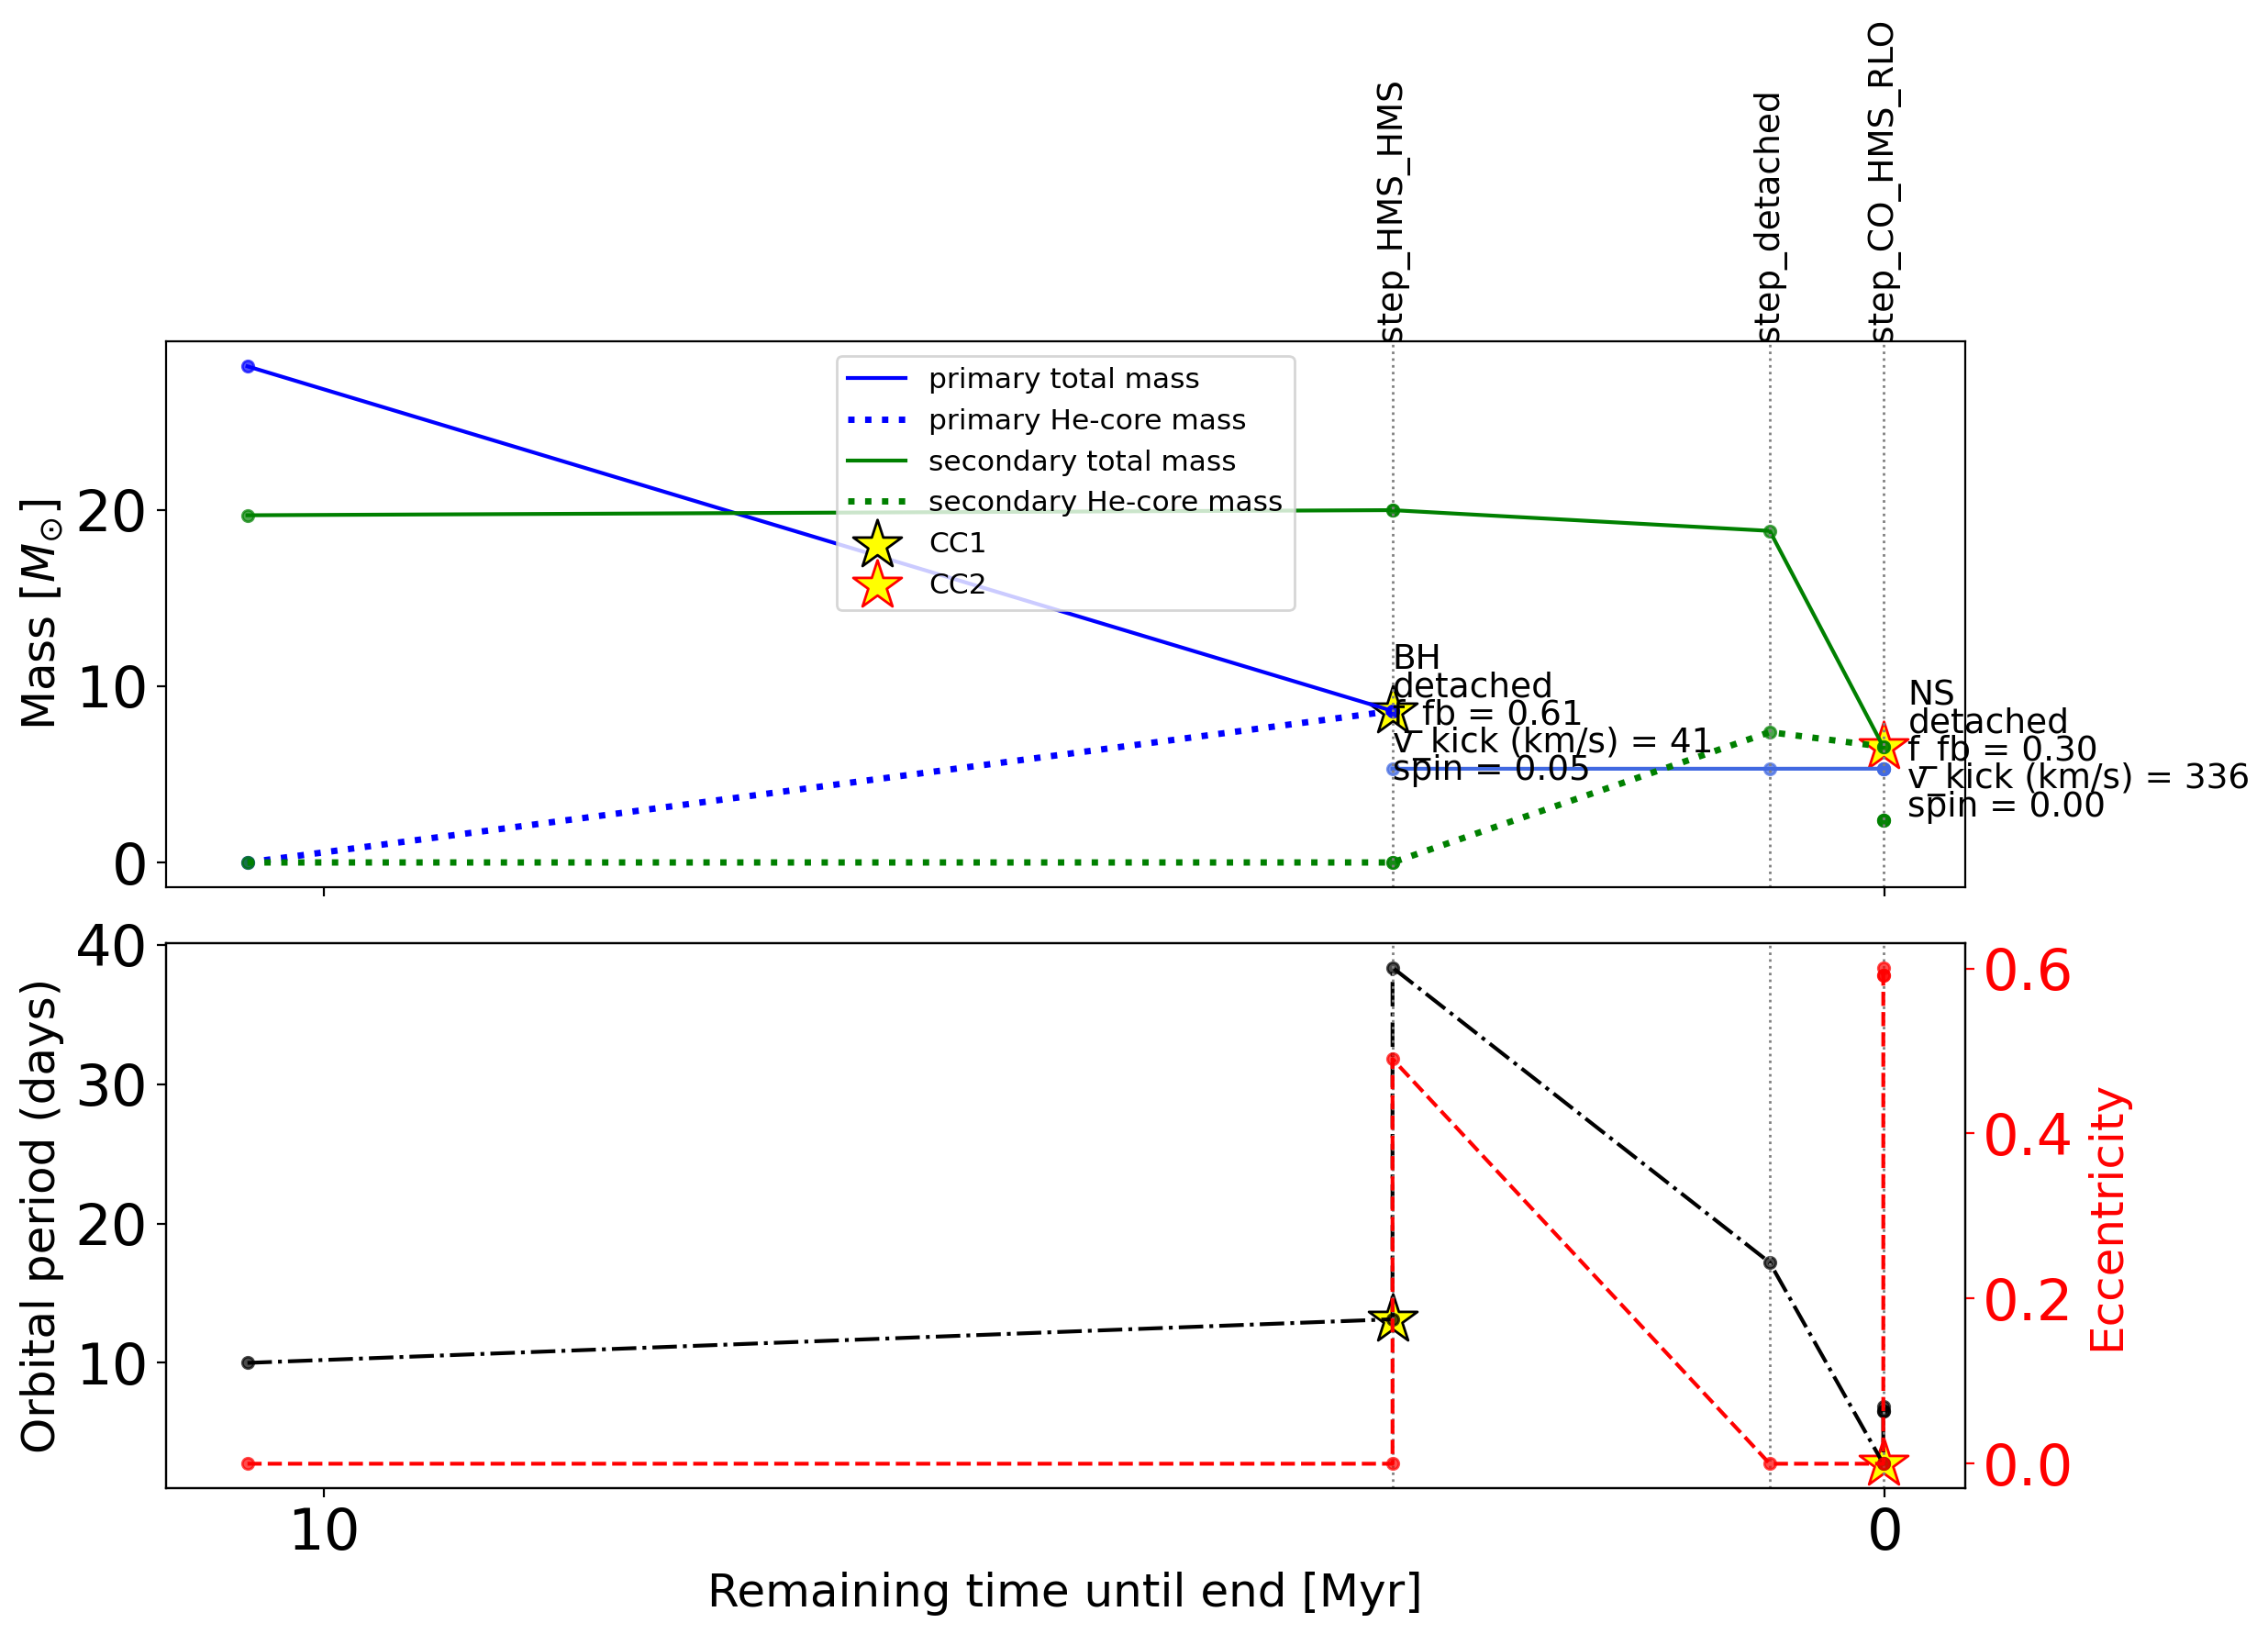

,step_names,state,time,S1_state,S2_state,event
binary_index,,,,,,
NaN,initial_cond,detached,0.000000e+00,H-rich_Core_H_burning,H-rich_Core_H_burning,ZAMS
NaN,step_HMS_HMS,detached,7.334459e+06,stripped_He_Core_C_depleted,H-rich_Core_H_burning,CC1
NaN,step_SN,detached,7.334459e+06,BH,H-rich_Core_H_burning,<NA>
NaN,step_detached,RLO2,9.750412e+06,BH,H-rich_Shell_H_burning,oRLO2
NaN,step_CO_HMS_RLO,detached,1.048794e+07,BH,stripped_He_Core_C_depleted,CC2
NaN,step_SN,detached,1.048794e+07,BH,NS,<NA>
NaN,step_dco,detached,1.380000e+10,BH,NS,maxtime
NaN,step_end,detached,1.380000e+10,BH,NS,END


In [6]:
from plotting_functions_CC  import plot_SN_evolution # a function made for this lab to visualize the time evolution of a systems, focusing on its CC1/2 properties
plot_SN_evolution(df, df_oneline)
col=["step_names","state","time", "S1_state", "S2_state","event"]
df[col]

When visualizing the binary evolution over time, POSYDON normally retains only the values at the end of each evolutionary step. Thus, with the initial/final interpolation of the MESA grids, the detailed internal time evolution within each step, such as the changes during mass transfer and binary interactions, is not resolved. We still follow the main outcomes, including the compact object formed after `CC1` or `CC2`, whether the binary remains bound, the natal kick, and, for a BH, its spin. 

A more detailed time evolution is explored in the optional section at the end of this Lab.

<div class="alert alert-success">

## Exercise: 
To become more familiar with commonly used supernova parameters and where they are stored (in the `history` or `oneline` keys), print key information for the system above. This should include the fallback fraction, the amounts of hydrogen and helium ejected during the SN event,  the kick magnitude at `CC1`, and whether the system was disrupted or remained bound after `CC1`.
   
</div>

In [ ]:
print(### fill in ###)
print(### fill in ###)
print(### fill in ###)
print(### fill in ###)
print(### fill in ###)

<div class="alert alert-warning" style="margin-top: 20px">
<details>

<b><summary>Hint 1</summary></b>

All this information is stored as columns in `df_oneline` except the `step_names` stored in `df`. The corresponding columns are organized as follows:

`f_fb`: fallback fraction

`h1_mass_ej`: hydrogen mass in the ejecta

`he4_mass_ej`: helium mass in the ejecta

magnitude of the kick: `S1_natal_kick_velocity`

The state of the binary after `CC1` is stored in `binary.state`, corresponding to the `state` column in the row where `step_names == "step_SN"`. Careful: The row with `event == "CC1"` represents the pre-SN state that triggers `step_SN`, rather than its outcome.

    
</details>

<div class="alert alert-warning" style="margin-top: 20px">
<details>

<b><summary>Solution</summary></b>
```python
print("fallback fraction:", df_oneline["S1_f_fb"].values)
print("H mass in the ejecta in solar masses",df_oneline["S1_h1_mass_ej"].values)
print("He mass in the ejecta in solar masses", df_oneline["S1_he4_mass_ej"].values)
print("kick magnitude:",df_oneline["S1_natal_kick_velocity"].values)
post_CC1 = (df["step_names"] == "step_SN") & (df["event"].shift(1) == "CC1")
print("state of the binary after CC1:", df.loc[post_CC1, "state"].values)
```
    
</details>

## 2. `step_SN` options in POSYDON

Now, let's explore the impact of modifying the parameters available for `step_SN` in the `.ini` file. First, we'll review the options available. For a more detailed explanation of each parameter, refer to the POSYDON documentation for `step_SN`:    
https://posydon.org/POSYDON/latest/_modules/posydon/binary_evol/SN/step_SN.html


```python
[step_SN]
  import = ['posydon.binary_evol.SN.step_SN', 'StepSN']
    # builtin posydon step
  absolute_import = None
    # 'package' kwarg for importlib.import_module
  
  # -------------------------------
  # Explosion Mechanisms
  # -------------------------------
  mechanism = 'Fryer+12-delayed'
    # available options: 'Fryer+12-rapid', 'Fryer+12-delayed',
    #                    'Sukhbold+16-engine', 'Patton&Sukhbold20-engine',
    #                    'Couch+20-engine', 'Maltsev+25-engine',
    #                    'direct', 'direct_he_core'
  engine = ''
    # mechanism-dependent options:
    # 'N20', 'S19.8', 'W15', 'W20', 'W18' for Sukhbold+16-engine
    # 'N20', 'S19.8', 'W15', 'W20', 'W18', 'Ertl2020' for Patton&Sukhbold20-engine
    # '1.0', '1.2', '1.23', '1.25', '1.27', '1.3', '1.4' for Couch+20-engine
    # 'M16' for Maltsev+25-engine
    # '' for the others
  ECSN = "Tauris+15"
    # "Tauris+15", "Podsiadlowski+04"

  # -------------------------------
  # Mass and neutrino loss
  # -------------------------------
  conserve_hydrogen_envelope = False
    # True, False
  max_neutrino_mass_loss = 0.5
    # float (0,inf)
    # v2 interpolators support: 0.5
  max_NS_mass = 2.5
    # float (0,inf)
    # v2 interpolators support: 2.5

  # -------------------------------
  # P(P)ISN options 
  # -------------------------------
  PISN = "Hendriks+23"
    # v2 interpolators support: "Hendriks+23"
    # other options: None, "Marchant+19"
  PISN_CO_shift = 0.0
    # Only when using Hendriks+23
    # float (-inf,inf)
    # v2 interpolators support: 0.0
  PPI_extra_mass_loss = -20.0
    # Only when using Hendriks+23
    # float (-inf,inf)
    # v2 interpolators support: 0.0 or -20.0
  conserve_hydrogen_PPI = False
    # Only when using Hendriks+23
    # True, False


  # -------------------------------
  # interpolation options
  # -------------------------------
  use_interp_values = True
    # True, False
  use_profiles = True
    # True, False
  use_core_masses = True
    # True, False
  allow_spin_None = False
    # True, False
  approx_at_he_depletion = False
    # True, False


   # -------------------------------
  # kick options
  # -------------------------------
  kick = True
    # True, False
  kick_prescription = 'maxwellian'
    # default: "maxwellian"; other options: "log_normal", "asym_ej", "linear"
  kick_normalisation = 'one_over_mass'
    # "one_minus_fallback", "one_over_mass", "NS_one_minus_fallback_BH_one",
    # "one", "zero"

  sigma_kick_CCSN_NS = 265.0
    # default Maxwellian sigma [km/s]; use 0.68 for default "log_normal"
  mean_kick_CCSN_NS = None
    # "log_normal" only; None -> exp(5.60) ~ 270 km/s

  sigma_kick_CCSN_BH = 265.0
    # default Maxwellian sigma [km/s]; use 0.68 for default "log_normal"
  mean_kick_CCSN_BH = None
    # "log_normal" only; None -> exp(5.60) ~ 270 km/s

  sigma_kick_ECSN = 20.0
    # default Maxwellian sigma [km/s]; use 0.68 for default "log_normal"
  mean_kick_ECSN = None
    # "log_normal" only; None -> exp(5.60) ~ 270 km/s
    
```    

### 2.1 Varying Supernova Kicks

Let’s draw kicks from a Maxwellian distribution, with dispersions of 60 km/s for NSs. BHs receive natal kicks with the same dispersion, scaled by the BH mass ($𝑀_{BH}$) with $1.4 \, M_{\odot}$ / $𝑀_{BH}$. First, let’s revert the kick to be randomly drawn from its distribution:

In [ ]:
STAR1, STAR2 = (SingleStar(**{'mass': m1_init, 'state': 'H-rich_Core_H_burning',
                             'natal_kick_velocity': None,
                             'natal_kick_azimuthal_angle': None,
                             'natal_kick_polar_angle': None,
                             'natal_kick_mean_anomaly': None}),
               SingleStar(**{'mass': m2_init, 'state': 'H-rich_Core_H_burning'}))
    
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)

In [ ]:
sim_prop.load_a_step("step_SN", (StepSN, {'sigma_kick_CCSN_NS': 60, 'sigma_kick_CCSN_BH': 60}))
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)
binary.evolve()

df60_oneline = binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)
df60 = binary.to_df(extra_columns={'step_names':'string'})
plot_SN_evolution(df60, df60_oneline)

Let’s now draw kicks from a Maxwellian distribution, with dispersions of 20 km/s for NSs. BHs receive natal kicks with the same dispersion, scaled by the BH mass ($𝑀_{BH}$) with 1.4 $M_{\odot}$ / $𝑀_{BH}$.

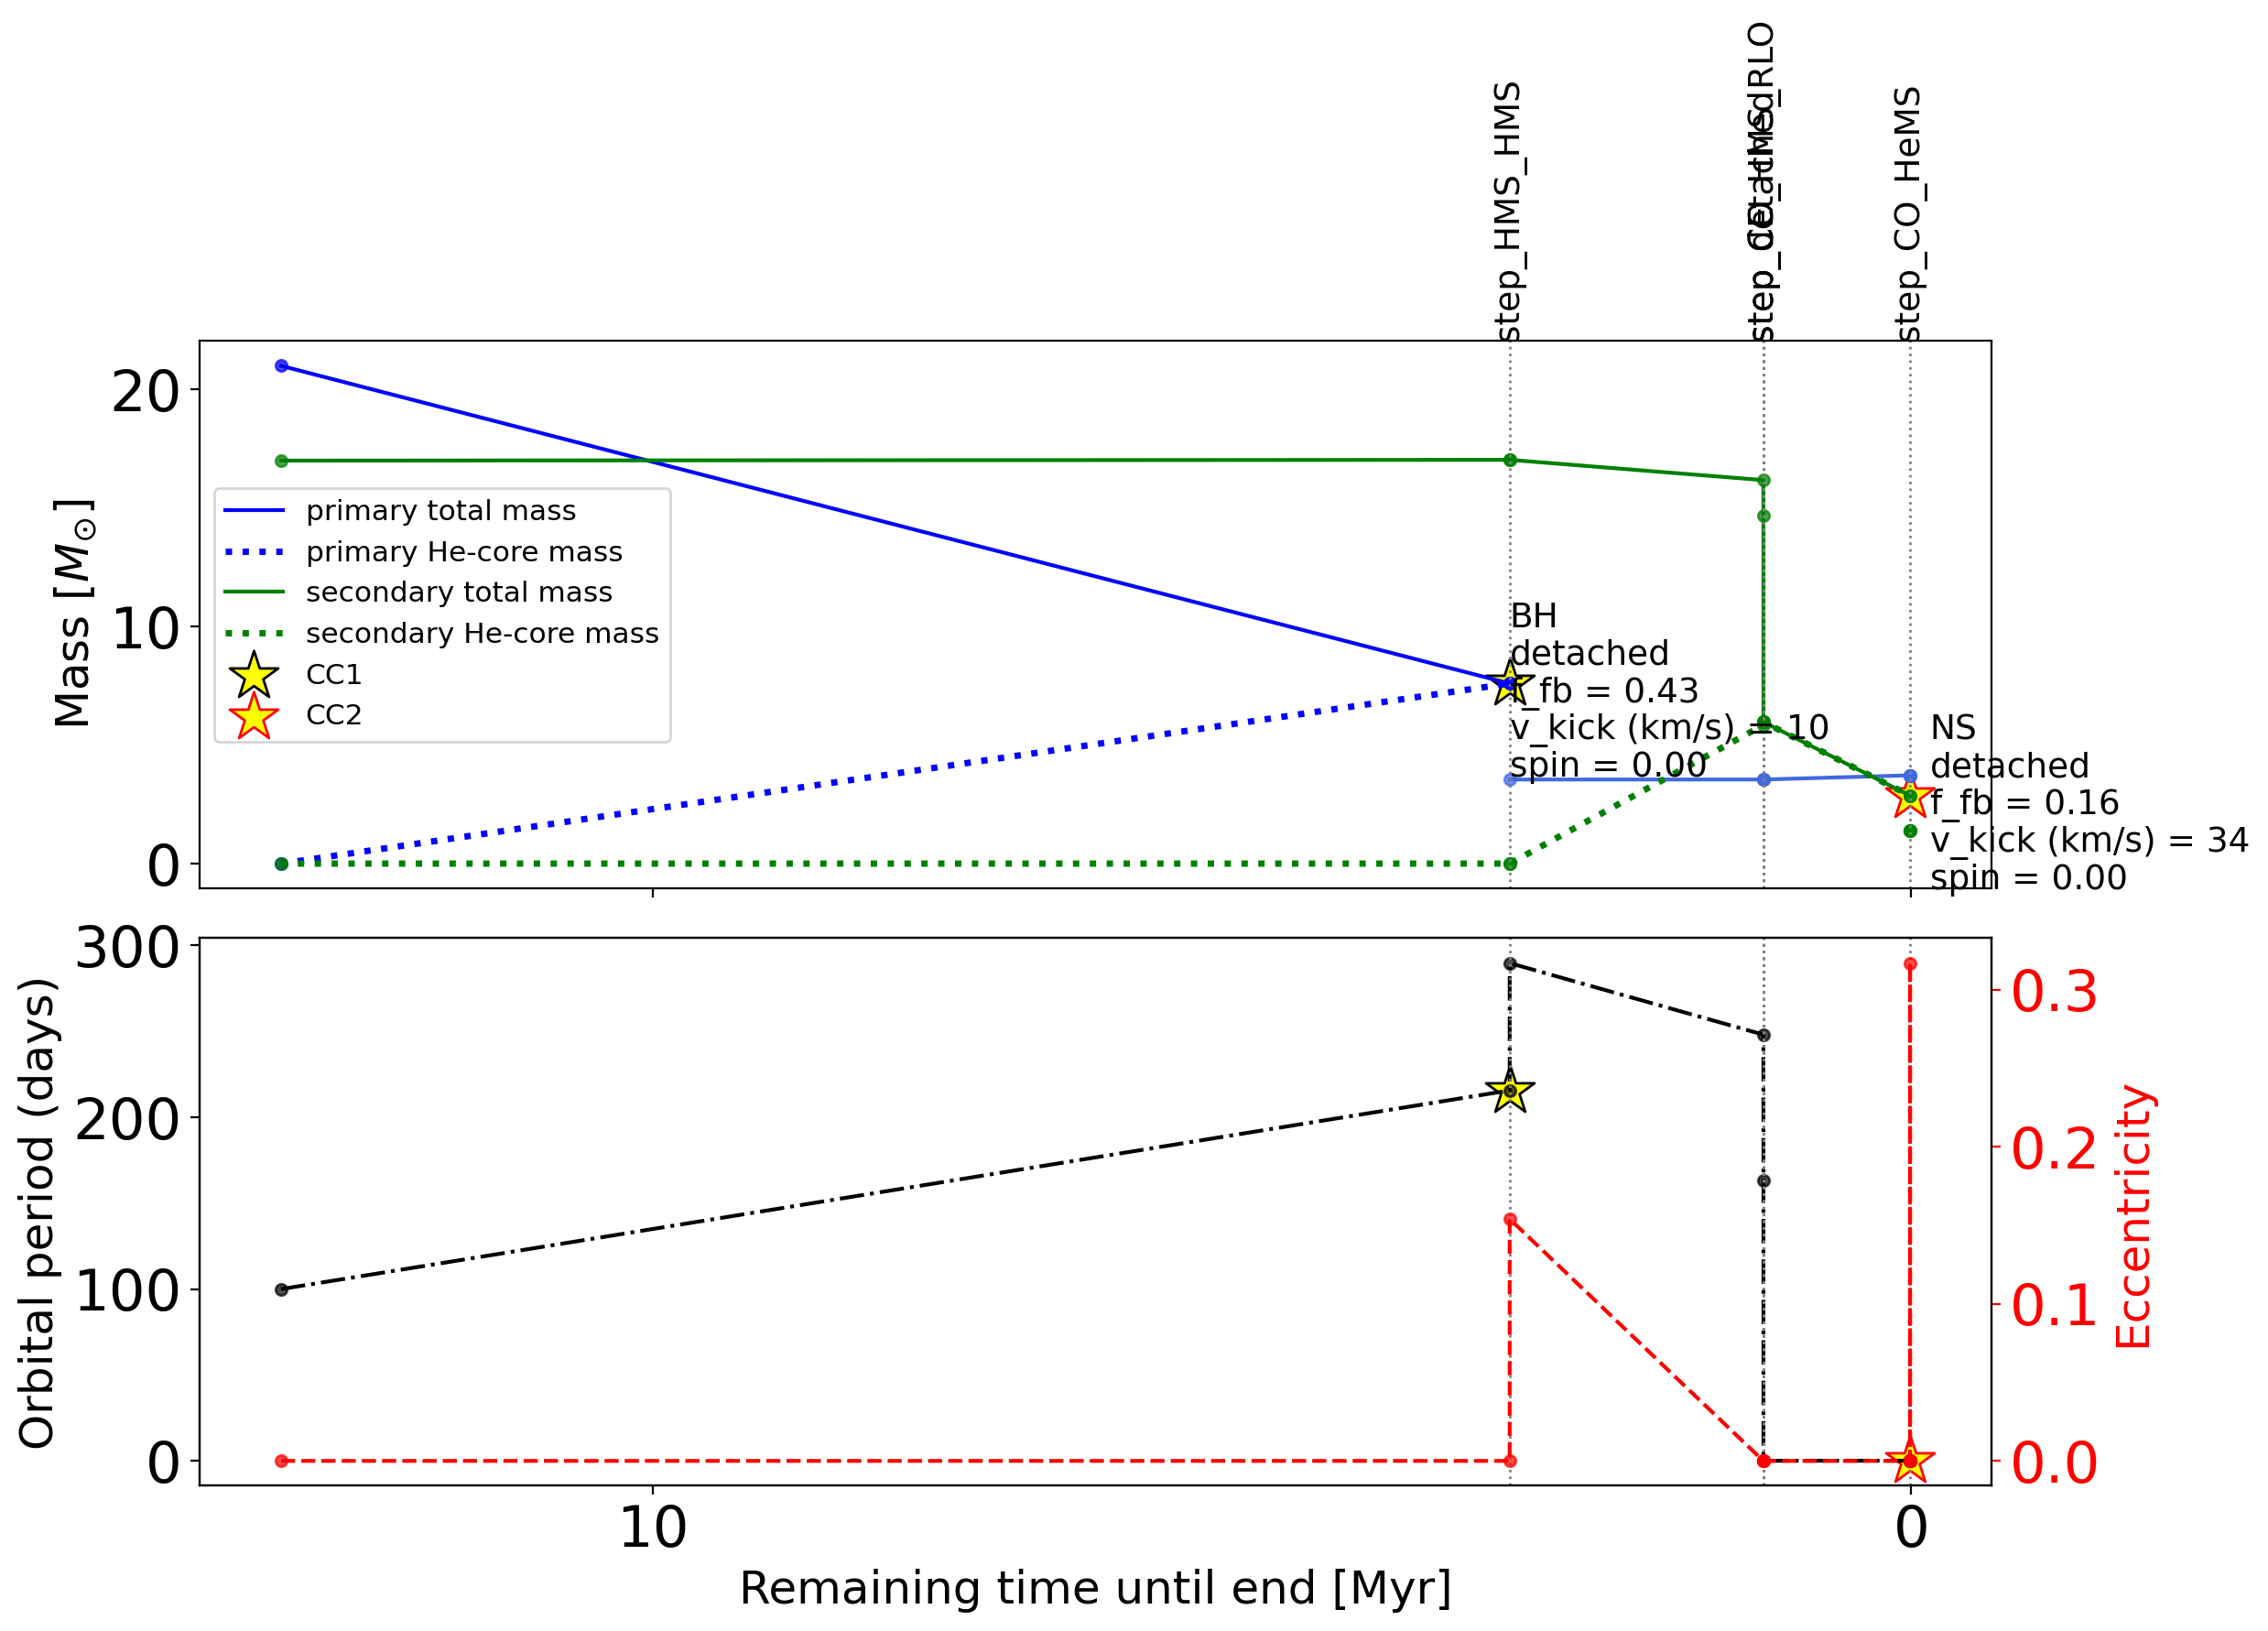

In [109]:
sim_prop.load_a_step("step_SN", (StepSN, {'sigma_kick_CCSN_NS': 20, 'sigma_kick_CCSN_BH': 20}))
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)
binary.evolve()
df_oneline=binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)
df=binary.to_df(extra_columns={'step_names':'string'})
plot_SN_evolution(df, df_oneline)

<div class="alert alert-success">

## Exercise:
1. Examine from the plots above how different the binary evolution and specifically the orbital parameters,  eccentricity and orbital period, is when we have lower SN kicks. Since no SN kick occurs before `CC1`, the evolution of the systems is identical up to this point.  

2. To remind ourselves how we extract the actual values from the run system, for the latest run (of the 20 km/s velocity dispersion) report the orbital separation immediately after `CC1` and determine whether the system remains bound.

</div>







In [111]:
print("Post-CC1 orbital period", ??)
print("Post-CC1 orbital eccentricity", ??)
print("Post-CC1 orbital separation", ??)

print("Kick :", ??)

SyntaxError: invalid syntax (2896525932.py, line 1)

<div class="alert alert-warning" style="margin-top: 20px">
<details>

<b><summary>Hint  for 2</summary></b>

The row with `event == "CC1"` marks the core-collapse event, while the outcome of `step_SN` is stored in the following row. Think about how shifting the `event` column by one row using `.shift(1)` allows you to identify that post-`CC1` row.

    
</details>

<div class="alert alert-warning" style="margin-top: 20px">
<details>

<b><summary>Solution</summary></b>

 
```python
post_CC1 = df["event"].shift(1) == "CC1" # we check the next line after CC1 (i.e. the outcome of step_SN triggered by CC1 event)

print("Post-CC1 binary state:", df.loc[post_CC1, "state"].values[0])
print("Post-CC1 orbital period:", df.loc[post_CC1, "orbital_period"].values[0], "days")
print("Post-CC1 orbital eccentricity:", df.loc[post_CC1, "eccentricity"].values[0])
print("Post-CC1 orbital separation:", df.loc[post_CC1, "R_solar"].values[0], "R_sun")

print("Kick :",df_oneline["S1_natal_kick_velocity"].values[0], "km/s")

```

    
</details>

### 2.1.1 Counting Disruptions After `CC1`

<div class="alert alert-success">

## Exercise:

1. Rerun a binary system 20 times. This time, we have adjusted the initial parameters so that the primary evolves into a neutron star. Choose any value for the velocity dispersion of the Maxwellian natal-kick distribution for a neutron star (`sigma_kick_NS`) using the script provided below (simply set the value of `sigma_kick_NS`). In each trial, the actual kick should still be randomly drawn from the distribution. How many of the 20 runs lead to system disruption?

2. Repeat the experiment with several different choices of `sigma_kick_NS`. Can you identify an approximate value of `sigma_kick_NS` that results in disruption in about half of the trials?

3. Compute the Keplerian orbital velocity of the binary before first core collapse (`CC1`).

4. For the disrupted systems, compare the natal kick velocities with the pre-CC orbital velocity. What trends or patterns do you observe?


</div>







In [ ]:
import numpy as np
from posydon.utils import constants as cs #cgs

m1_init = 13 # in Msun 
m2_init = 10 # in Msun
p_init = 100 # in days
STAR1, STAR2 = SingleStar(**{'mass': m1_init, 'state': 'H-rich_Core_H_burning'}), \
               SingleStar(**{'mass': m2_init, 'state': 'H-rich_Core_H_burning'})


sigma_kick_NS =  60 # please set this value!
n_repeat = 20
n_o_disruptions = 0
kicks_at_disruption = []

sim_prop.load_a_step("step_SN", (StepSN, {'sigma_kick_CCSN_NS': sigma_kick_NS})) 
for i in range(n_repeat):
    binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)
    binary.evolve()
    df_oneline=binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)
    df=binary.to_df(extra_columns={'step_names':'string'})
    
    mask_CC1 = (df['step_names'] == "step_SN") & (df['event'].shift(1) == "CC1") 
    v_kick_CC1 = df_oneline["S1_natal_kick_velocity"].values[0] #?
    state_after_CC1 = df.loc[mask_CC1, "state"].values[0] #?
    
    print(f"trial {i}: v_kick_CC1={v_kick_CC1:.0f} km/s, state_after_CC1={state_after_CC1}")
    
    if state_after_CC1 == "disrupted":
        n_o_disruptions += 1
        kicks_at_disruption.append(v_kick_CC1)
        
print("disruption percentage", n_o_disruptions/n_repeat*100., r"%")

if kicks_at_disruption:
    median_kick = np.median(kicks_at_disruption)
    print(f"median kick at disruption = {median_kick:.0f} km/s")
    
else:
    print("no disruptions, median kick undefined")

In [ ]:
# Step 3

import numpy as np
from posydon.utils import constants as cs #cgs

G = cs.standard_cgrav

??

v =  ??

print("v_orbital_velocity_preCC1 (km/s):", ?? )

<div class="alert alert-warning" style="margin-top: 20px">

<details>
<summary><b>Hint for step 3</b></summary>
For a circular binary with masses \(m_1, m_2\), total mass \(M=m_1+m_2\), and separation \(a\), the relative orbital velocity is


$$
v = \sqrt{\frac{GM}{a}}
$$

</details>


<div class="alert alert-warning" style="margin-top: 20px">
<details>

<b><summary>Solution</summary></b>

```python

import numpy as np
from posydon.utils import constants as cs #cgs

G = cs.standard_cgrav

mask_CC1 = df['event'] == "CC1" #& df['step_names'].shift(-1) == "CC1"
m1 = df.loc[mask_CC1, "S1_mass"] * cs.Msun
m2 = df.loc[mask_CC1, "S2_mass"] * cs.Msun
a  = df.loc[mask_CC1, "separation"] * cs.Rsun

Mtot   = m1 + m2
v =  np.sqrt((G*Mtot) / a)  # cm/s

print("v_orbital_velocity_preCC1 (km/s):", (v/1e5).values[0])
```

<p>
We can observe that, as a rule of thumb, disrupting a binary requires a SN kick comparable to or larger than the pre-SN orbital velocity.
</p>

<p>
<b>Physical intuition:</b> The kick must change the remnant's velocity sufficiently to overcome the gravitational binding of the binary. Of course, the outcome also depends on the kick direction (not only the magnitude), as it is added vectorially to the pre-SN orbital velocity of the newly formed compact remnant. The instantaneous mass loss during the SN also weakens the binary’s gravitational binding.
</p>

</details>

### 2.2 Different SN mechanisms

Here you will learn how to switch to a different SN mechanism. Specifically, instead of the `Fryer+12-delayed` prescription which is used in the example below, you will switch to `mechanism = Patton&Sukhbold20-engine` (with the Ertl explodability criterion) and `engine = N20`.

We evolve the binary below, firstly with `Fryer+12-delayed`. We will also select unrealistically high kicks, to force (almost deterministically) a disruption after CC1

/Users/zapartas/Desktop/work/POSYDON/POSYDON_Aug2026/POSYDON/posydon/binary_evol/SN/step_SN.py:591: InterpolationWarning: 'SN_MODEL_v2_01: The collapsed star was not interpolated! If use_profiles or use_core_masses is set to True, continue with the collapse.'


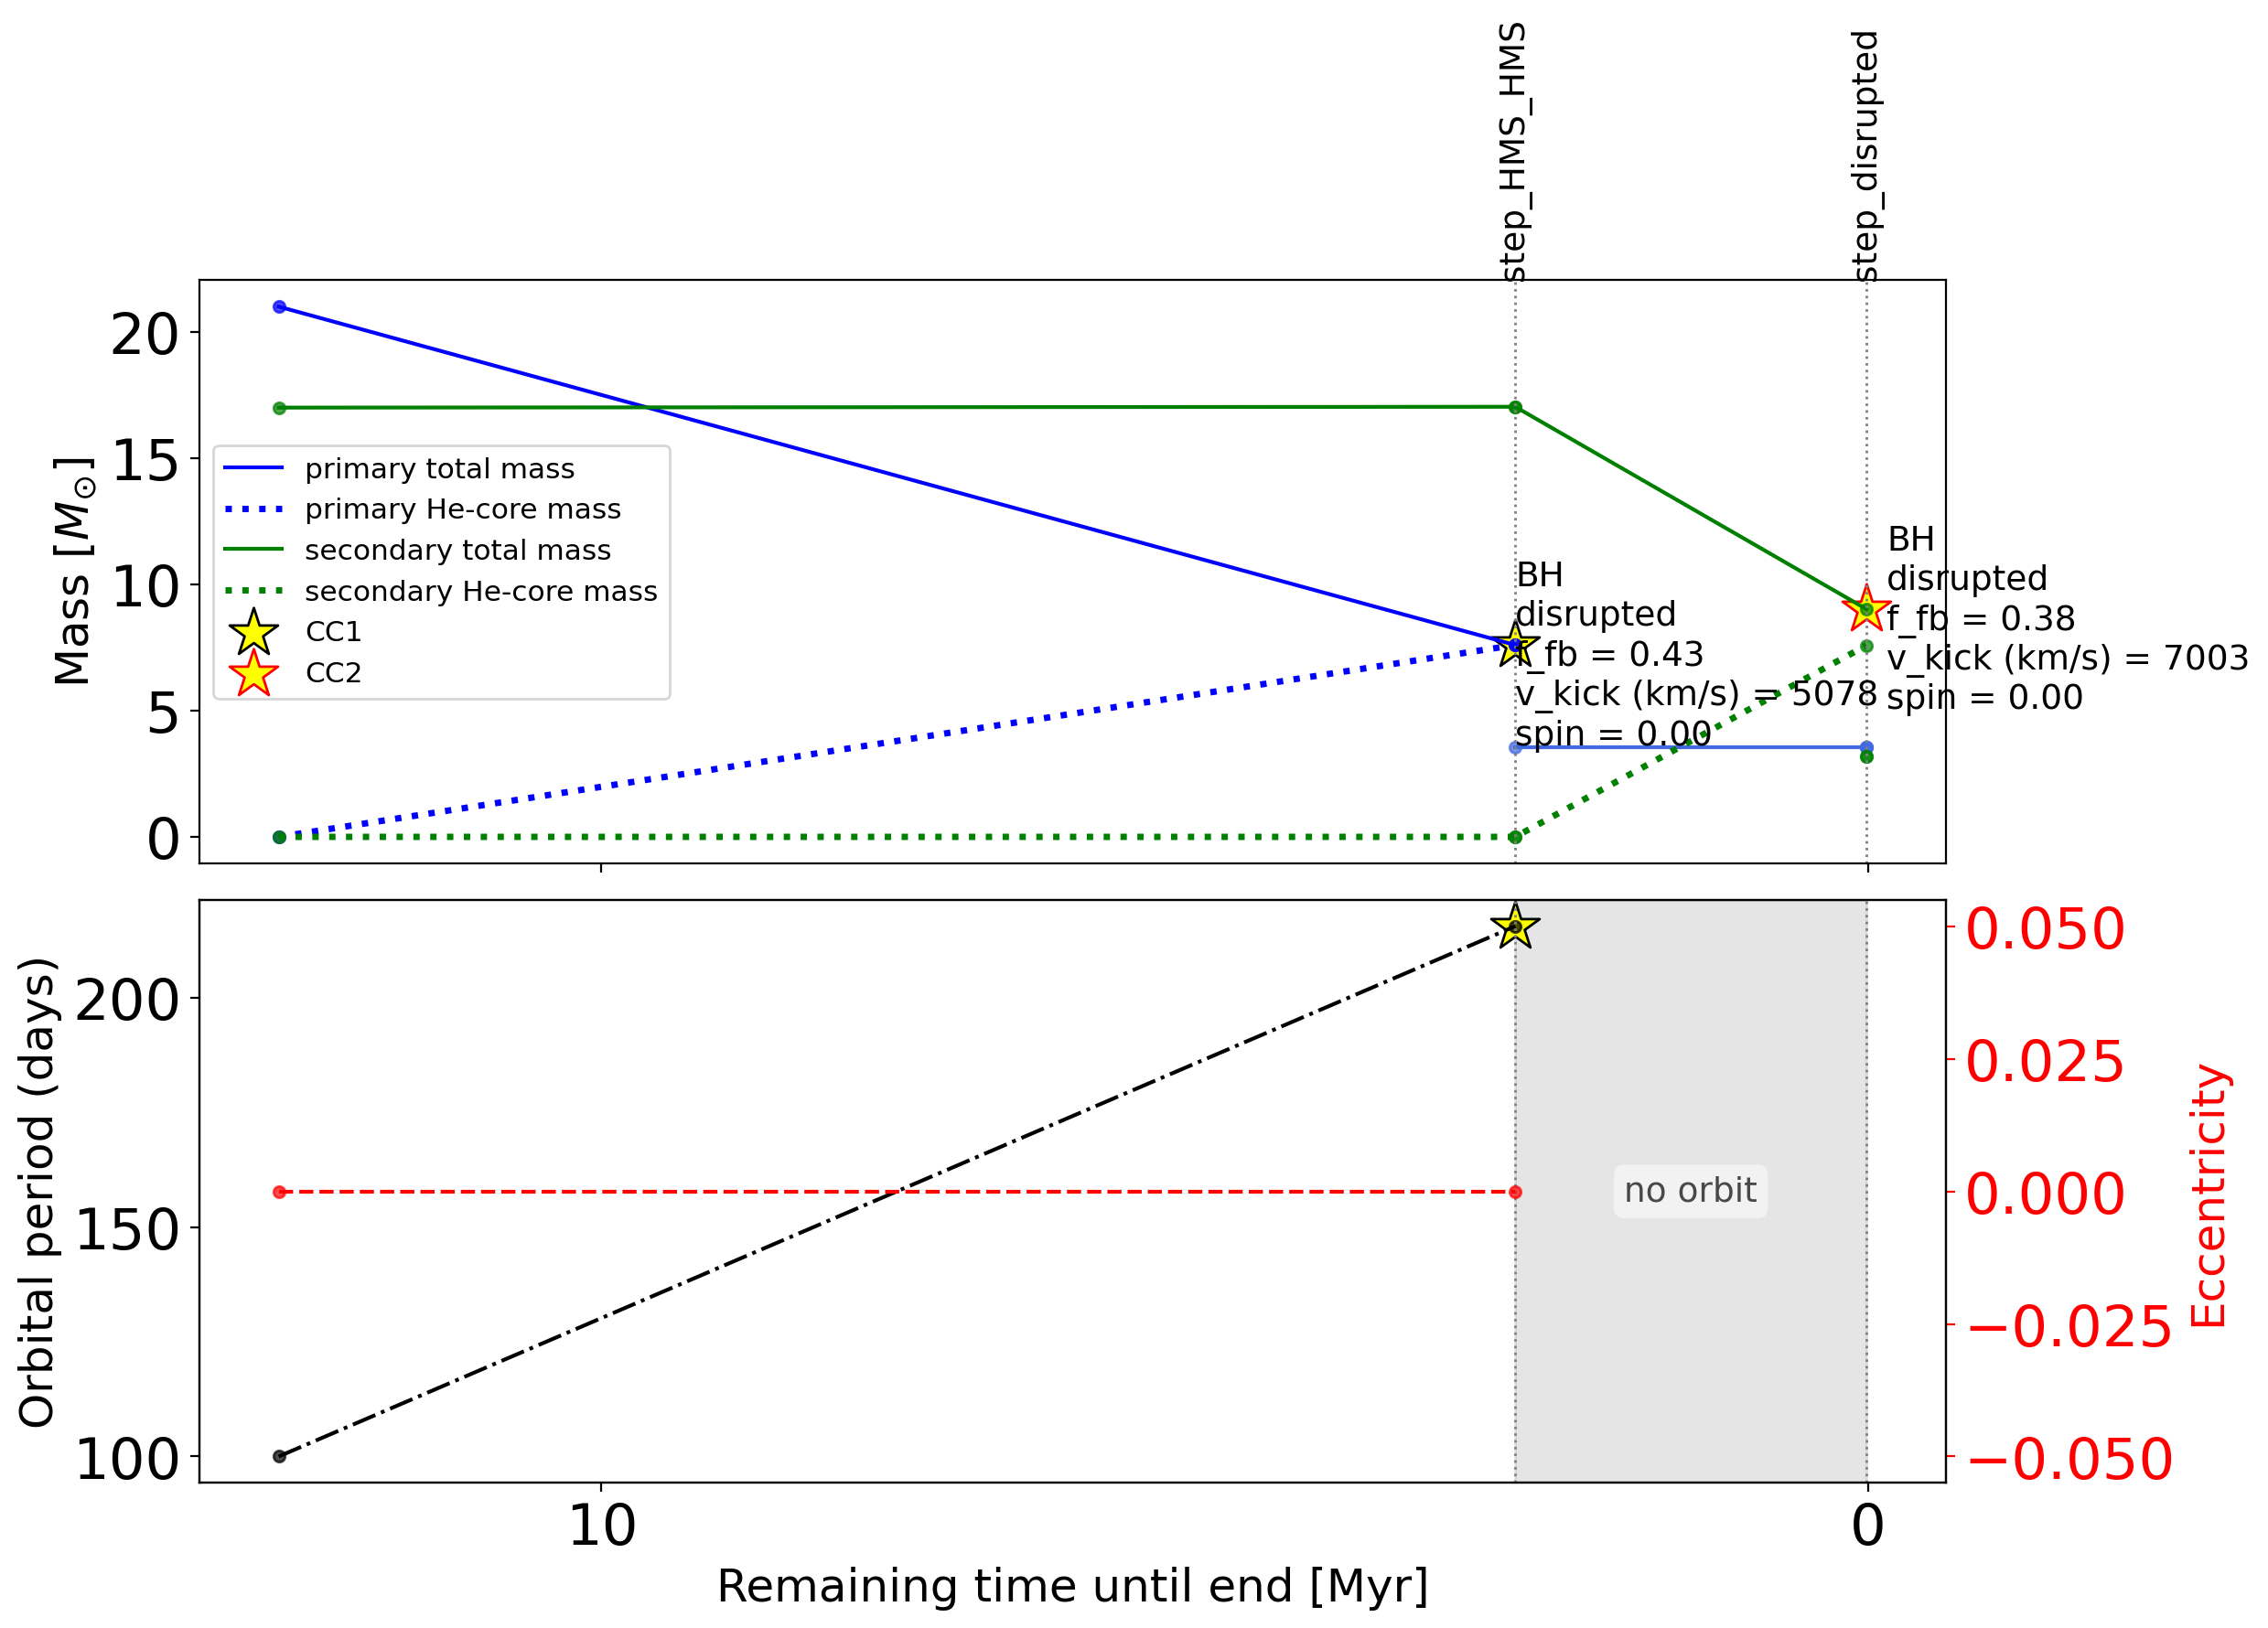

In [7]:
m1_init = 21 # in Msun 
m2_init = 17 # in Msun
p_init = 100 # in days
STAR1, STAR2 = SingleStar(**{'mass': m1_init, 'state': 'H-rich_Core_H_burning'}), \
               SingleStar(**{'mass': m2_init, 'state': 'H-rich_Core_H_burning'})

unr_kicks = {'sigma_kick_CCSN_NS': 10000, 'sigma_kick_CCSN_BH': 10000} # unrealistically high kicks
#sim_prop = SimulationProperties.from_ini(path_to_ini, load_steps=True, metallicity=1.0, verbose=False)
sim_prop.load_a_step("step_SN", (StepSN, {**unr_kicks, 'mechanism': 'Fryer+12-delayed', 'engine':''}))  #which is the default
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)

binary.evolve()

df_oneline=binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)
df=binary.to_df(extra_columns={'step_names':'string'})

plot_SN_evolution(df, df_oneline)

<div class="alert alert-success">

## Exercise: Change the SN prescription
Evolve the same binary as above, but this time set `mechanism = Patton&Sukhbold20-engine` and `engine = N20` in `step_SN`. Report the differences you observe compared to the latest run.  What changed at CC1 / CC2? 
   
</div>

In [ ]:
### fill in ###

<div class="alert alert-warning" style="margin-top: 20px">

<details>
<summary><b>Hint</b></summary>

```python
sim_prop.load_a_step("step_SN",(StepSN, {'mechanism': 'XX', 'engine': 'XX'})) #fill in XX
```
</details>

<div class="alert alert-warning" style="margin-top: 20px">

<details>

<b><summary>Solution</summary></b>

```python
sim_prop.load_a_step("step_SN", (StepSN, {**unr_kicks, 'mechanism': 'Patton&Sukhbold20-engine', 'engine':'N20'}))

binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)

binary.evolve()

df_oneline=binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)
df=binary.to_df(extra_columns={'step_names':'string'})

plot_SN_evolution(df, df_oneline)

# Now the primary forms a neutron star instead of a black hole!

```
    
</details>

<div class="alert alert-success">

## Exercise:
In the previous example, you found that the primary forms a NS rather than a BH. 

1. Report for both CC1 and CC2 the parameters that determine the outcome of the [Patton & Sukhbold (2020)](https://ui.adsabs.harvard.edu/abs/2020MNRAS.499.2803P/abstract) prescription, namely the carbon mass fraction at the core, ($X_{\rm C}$), and carbon–oxygen core mass, ($M_{\rm CO}$), both at core helium depletion (as saved in the oneline dataframe).
  
2. Report also the pre-CC structural parameters of [Ertl et al. (2016)](https://ui.adsabs.harvard.edu/abs/2016ApJ...818..124E/abstract): the mass coordinate ($M_4$) and mass gradient ($\mu_4$) at $s=4$ (the dimensionless entropy per nucleon, usually located at the base of the oxygen shell in a pre-SN model). Confirm that the extracted $M_4$ values are consistent with Image 1 from Patton+2020 paper.

3. In addition, compare the extracted values of $X_{\rm C}$ and $M_{\rm CO}$ at helium depletion with Image 2 below, which shows the predicted outcome based on the Ertl et al. (2016) explodability criterion. Confirm that the model predicts a successful explosion, forming a NS, for `CC1`, and an implosion, forming a BH, for `CC2`.
   
</div>

In [11]:
# Stellar core properties at central He depletion, before even carbon core depletion
print("S1 avg C fraction at CO core at He depletion:", ??)
print("S1 CO core mass at He depletion:", ??)

print("S2 avg C fraction at CO core at He depletion:", ??)
print("S2 CO core mass at He depletion:", ??)

SyntaxError: invalid syntax (543521569.py, line 2)

<div class="alert alert-warning" style="margin-top: 20px">
    
<details>
<summary><b>Hint</b></summary>
Check the  columns saved for each star in the oneline dataframe
</details>

<div class="alert alert-warning" style="margin-top: 20px">
<details>

<b><summary>Solution</summary></b>

```python 
# Stellar core properties at central He depletion, before even carbon core depletion
print("S1 avg C fraction at CO core at He depletion:", df_oneline["S1_avg_c_in_c_core_at_He_depletion"].values[0])
print("S1 CO core mass at He depletion:", df_oneline["S1_co_core_mass_at_He_depletion"].values[0])

print("S2 avg C fraction at CO core at He depletion:", df_oneline["S2_avg_c_in_c_core_at_He_depletion"].values[0])
print("S2 CO core mass at He depletion:", df_oneline["S2_co_core_mass_at_He_depletion"].values[0])

```
    
</details>

In [ ]:
# Mapping to the pre-SN core-structure parameters M4 and mu4 from Ertl+2016
print("S1 M_4:", ??)
print("S1 mu_4:", ??)

print("S2 M_4:", ??)
print("S2 mu_4:", ??)

<div class="alert alert-warning" style="margin-top: 20px">
<details>

<b><summary>Solution</summary></b>

```python 
# Mapping to the pre-SN core-structure parameters M4 and mu4 from Ertl+2016
print("S1 M_4:", df_oneline["S1_M4"].values[0])
print("S1 mu_4:", df_oneline["S1_mu4"].values[0])

print("S2 M_4:", df_oneline["S2_M4"].values[0])
print("S2 mu_4:", df_oneline["S2_mu4"].values[0])
```
    
</details>

Place the derived stellar parameters, $M_{\rm CO}$ and $X_{\rm C}$, on the corresponding $M_4$ mapping from Patton & Sukhbold (2020) to verify that the POSYDON values are extracted correctly.


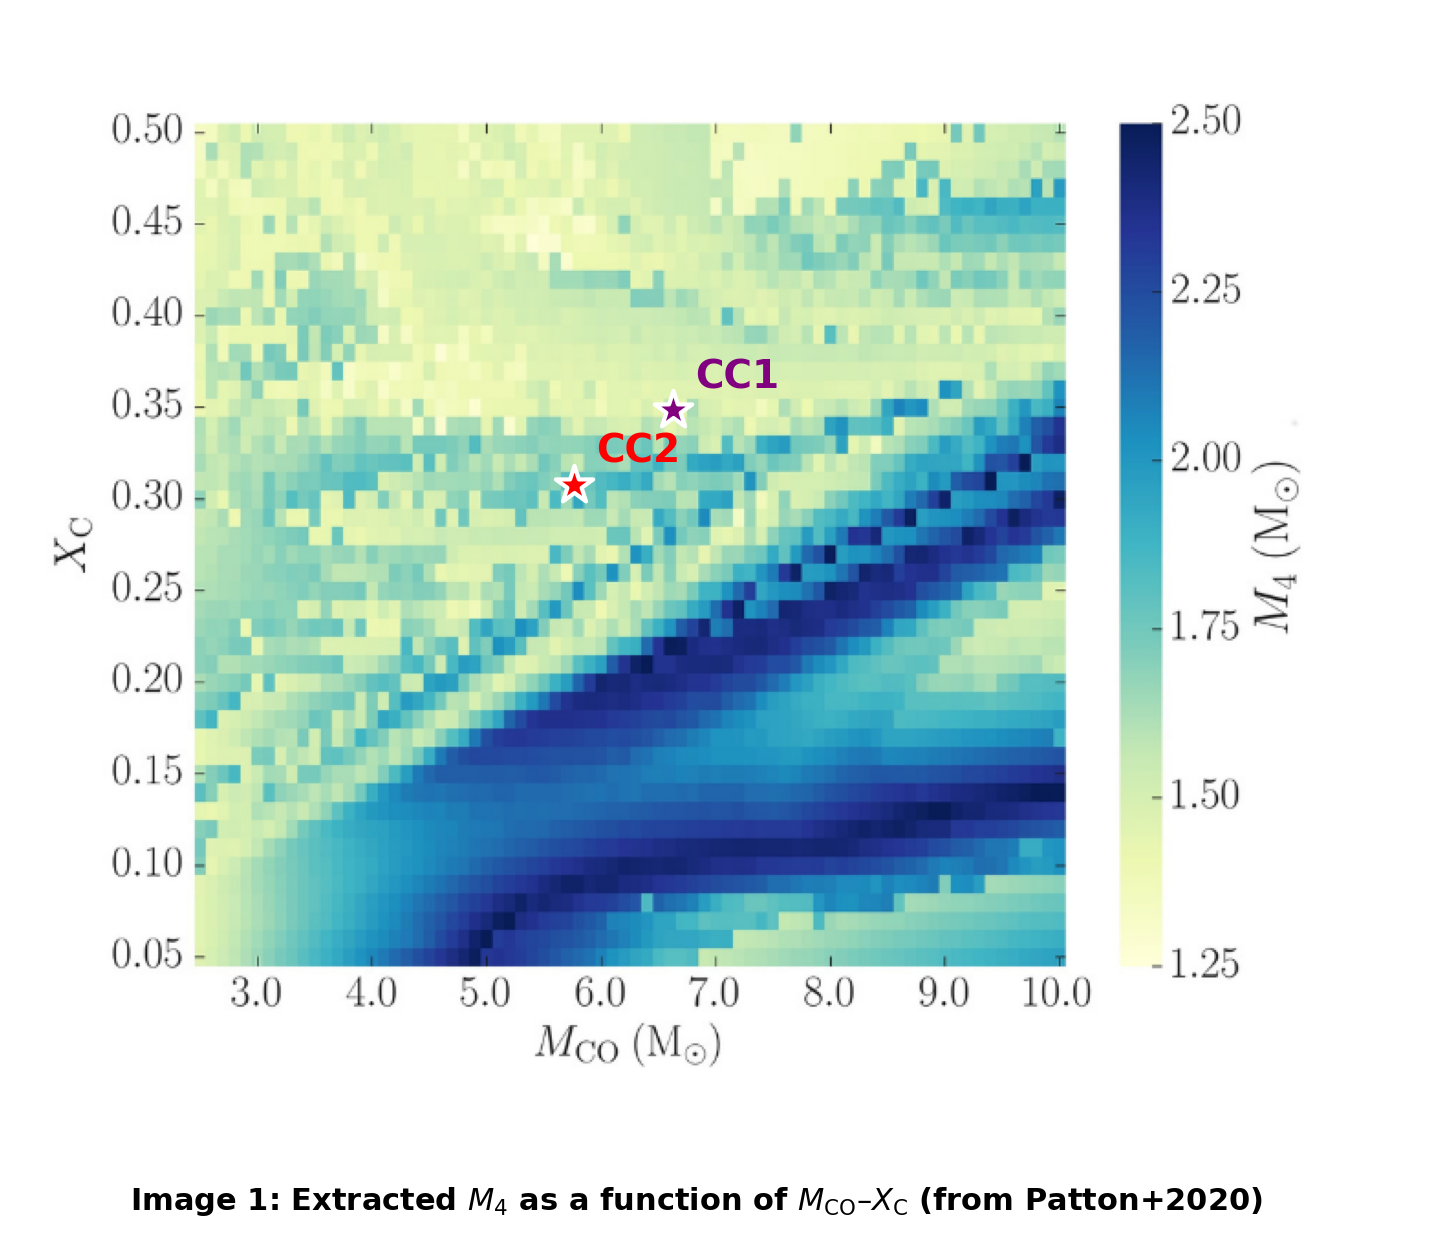

In [103]:
from plotting_functions_CC  import plot_M4_mapping
plot_M4_mapping(
    M_CO=[??, ??],  # M_CO of CC1 and CC2
    X_C=[??, ??],   # X_C of CC1 and CC2
    image_path="./Patton_M4.png"
)

Now again place the derived stellar parameters, $M_{\rm CO}$ and $X_{\rm C}$, on the corresponding 2D explodability mapping from Patton & Sukhbold (2020), based on the Ertl et al. (2016) explodability prescription, to understand why the CC1 successfully explodes and forms a NS, while CC2 implodes into a BH


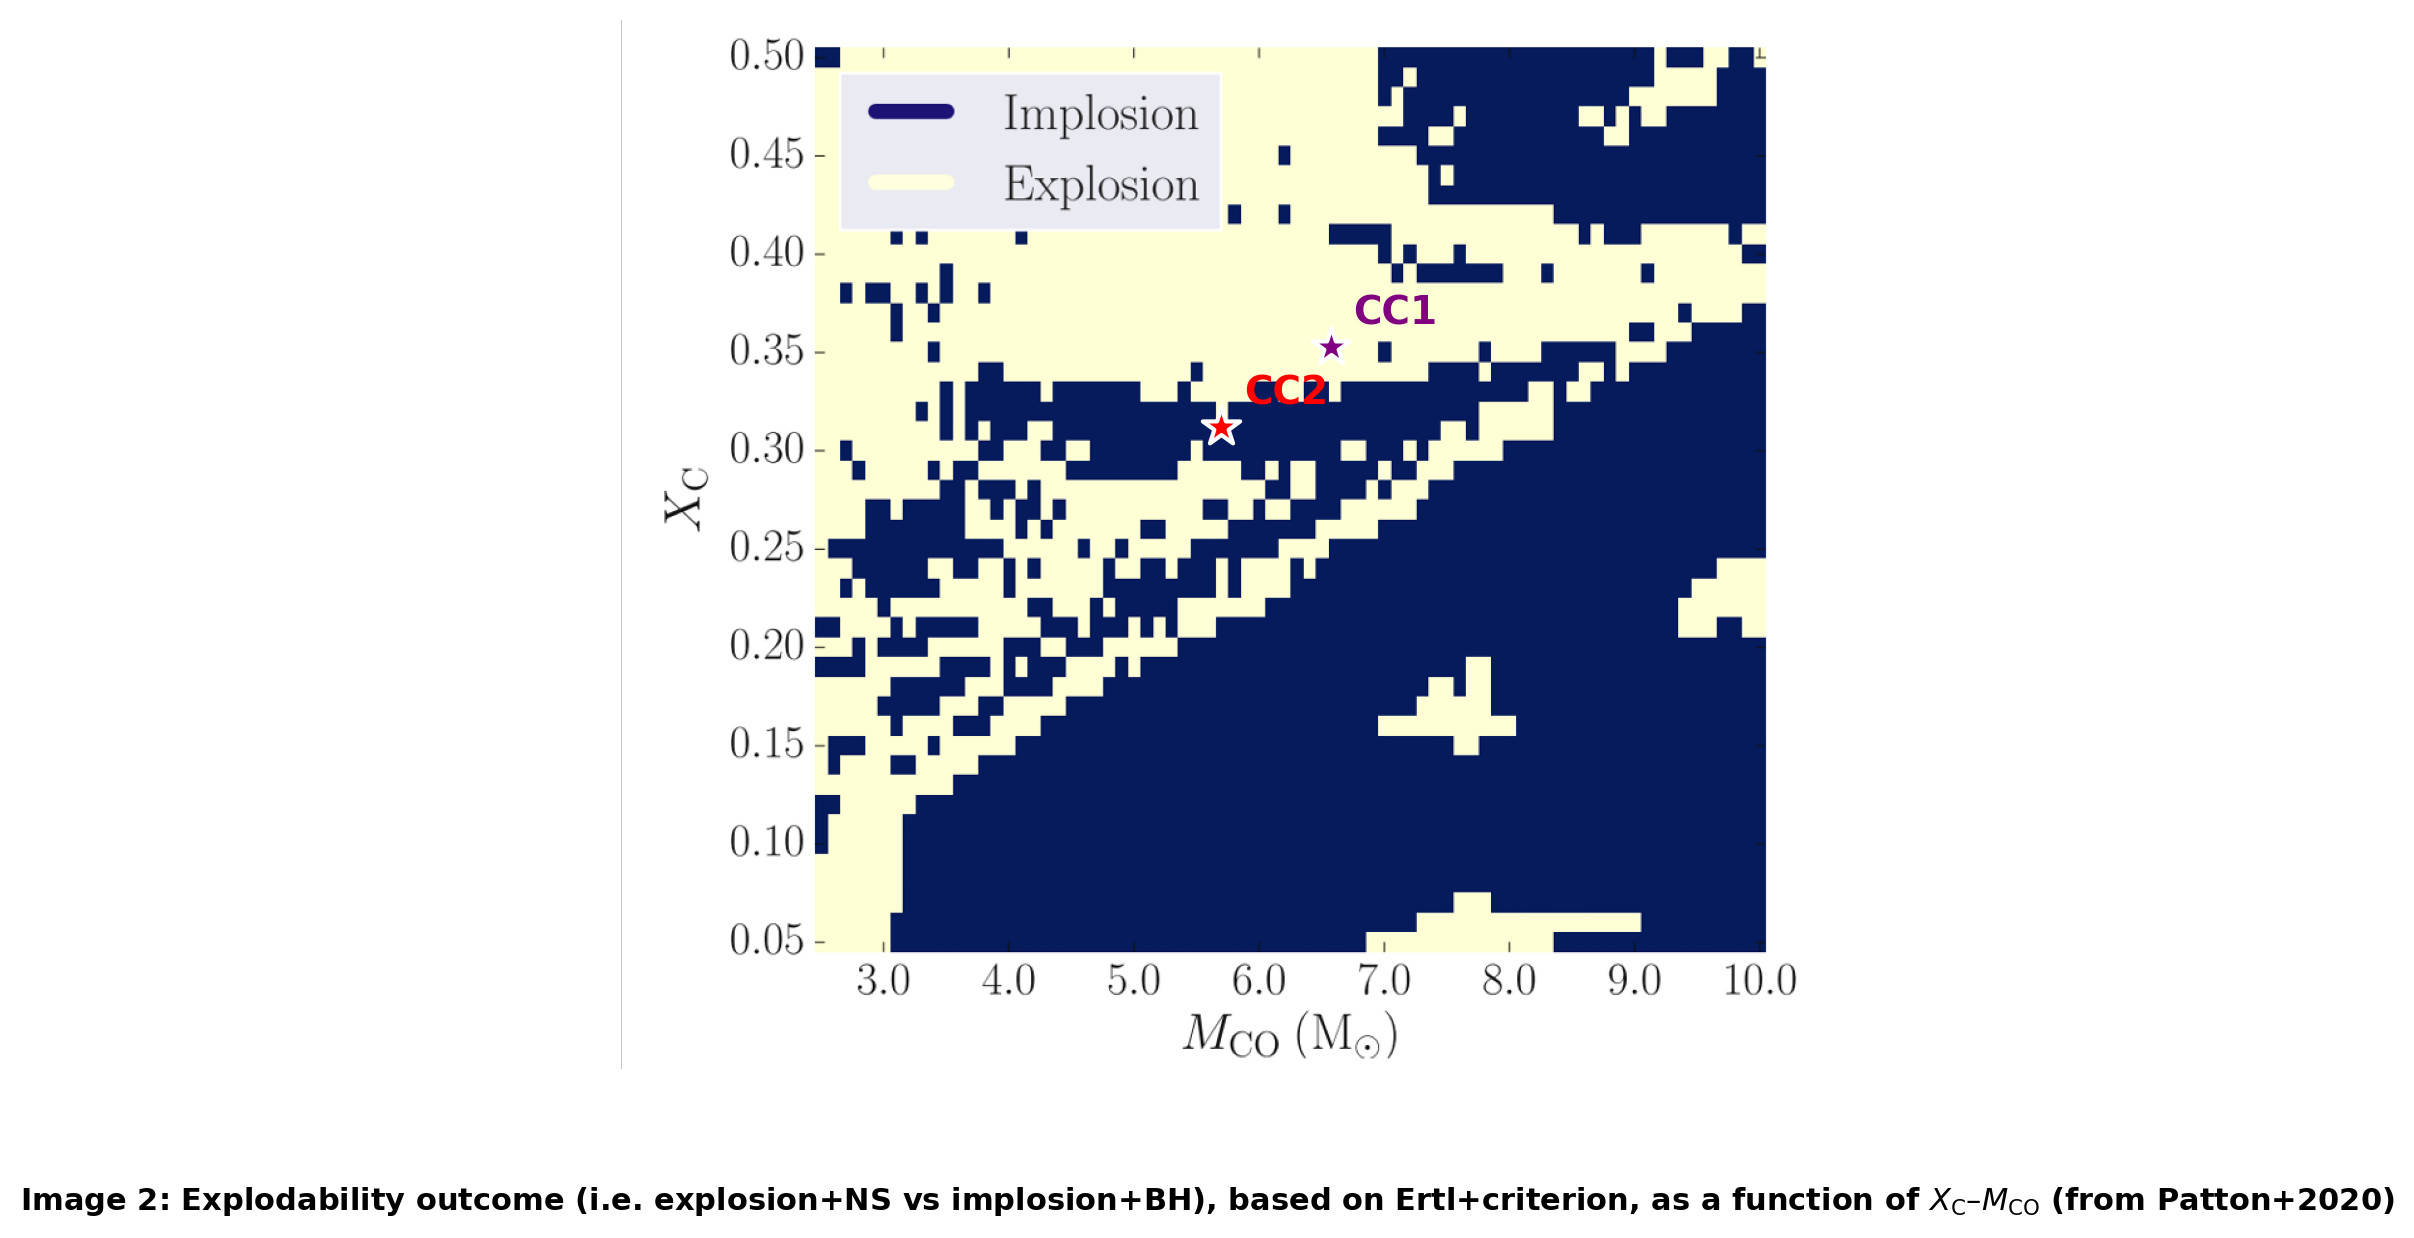

In [105]:
from plotting_functions_CC  import plot_M4_mapping
plot_M4_mapping(
    M_CO=[??, ??],  # M_CO of CC1 and CC2
    X_C=[??, ??],   # X_C of CC1 and CC2
    image_path="./Patton_explodability.png",
    plot_bounds=(150, 910, 20, 740), 
    show_plot_bounds=False
)

### 2.3 Interpolated SN_MODELS 

Having explored how to manually modify the assumptions in step_SN, we now examine in more detail how the post-CC values are calculated for each interpolation method.

For each point in the MESA grids (i.e. each MESA run), the post-CC outcome has already been computed for several sets of step_SN assumptions, called SN_MODELS. Each SN_MODEL adopts a fixed set of assumptions, including the SN mechanism/engine, PPISN mass-loss prescription, ECSN prescription, and treatment of the H-rich envelope during collapse, etc.

The precomputed post-CC values, on which we have trained an interpolator, can be therefore used in an initial/final interpolation in `step_MESA` (e.g., when using `interpolation_method = linear3c_kNN` in `step_MESA`). The interpolated values are adopted by setting `use_interp_values=True` in `step_SN`. When using `interpolation_method = nearest_neighbour` in `step_MESA`, we can alternatively also set `use_interp_values=False` and calculate the post-CC outcome on the fly.

Therefore, when using initial/final interpolation (which is the default in the POSYDON `.ini` file), the selected assumptions must correspond to one of the available `SN_MODELS`. Below, we examine the available `SN_MODELS` and learn how to import the assumptions of one of them for our run.

#### Check all `SN_MODELS` options

The available SN_MODELS and their corresponding assumptions are defined in the POSYDON `SN_MODELS` module:

- [POSYDON `SN_MODELS.py` source code](https://github.com/POSYDON-code/POSYDON/blob/8e5cee39ebd284d2153e719c51c8acf458225819/posydon/grids/SN_MODELS.py#L454)
- [POSYDON `SN_MODELS` documentation](https://posydon.org/POSYDON/latest/api_reference/posydon.grids.html#module-posydon.grids.SN_MODELS)

See also Table 4 of POSYDON v2 paper: Andrews et al. 2025 (which has been extended since).

In [ ]:
from posydon.grids.SN_MODELS import SN_MODELS
print(SN_MODELS.keys())

Print the SN parameters for one SN_MODEL

In [26]:
from posydon.grids.SN_MODELS import get_SN_MODEL

MODEL_parameters=get_SN_MODEL('SN_MODEL_v2_21')
MODEL_parameters

{'mechanism': 'Patton&Sukhbold20-engine',
 'engine': 'W20',
 'PISN': 'Hendriks+23',
 'PISN_CO_shift': 0.0,
 'PPI_extra_mass_loss': -20.0,
 'ECSN': 'Tauris+15',
 'conserve_hydrogen_envelope': False,
 'conserve_hydrogen_PPI': False,
 'max_neutrino_mass_loss': 0.5,
 'max_NS_mass': 2.5,
 'use_interp_values': False,
 'use_profiles': True,
 'use_core_masses': False,
 'allow_spin_None': False,
 'approx_at_he_depletion': False}

You may notice that the SN_MODELS have `use_interp_values = False` by default. When importing them and updating the default `.ini` file simulation propoerties of `step_SN`, we need to set use_interp_values to True. Let’s look at an example.

In [29]:
MODEL_parameters=get_SN_MODEL('SN_MODEL_v2_21')
MODEL_parameters["use_interp_values"] = True
MODEL_parameters

{'mechanism': 'Patton&Sukhbold20-engine',
 'engine': 'W20',
 'PISN': 'Hendriks+23',
 'PISN_CO_shift': 0.0,
 'PPI_extra_mass_loss': -20.0,
 'ECSN': 'Tauris+15',
 'conserve_hydrogen_envelope': False,
 'conserve_hydrogen_PPI': False,
 'max_neutrino_mass_loss': 0.5,
 'max_NS_mass': 2.5,
 'use_interp_values': True,
 'use_profiles': True,
 'use_core_masses': False,
 'allow_spin_None': False,
 'approx_at_he_depletion': False}

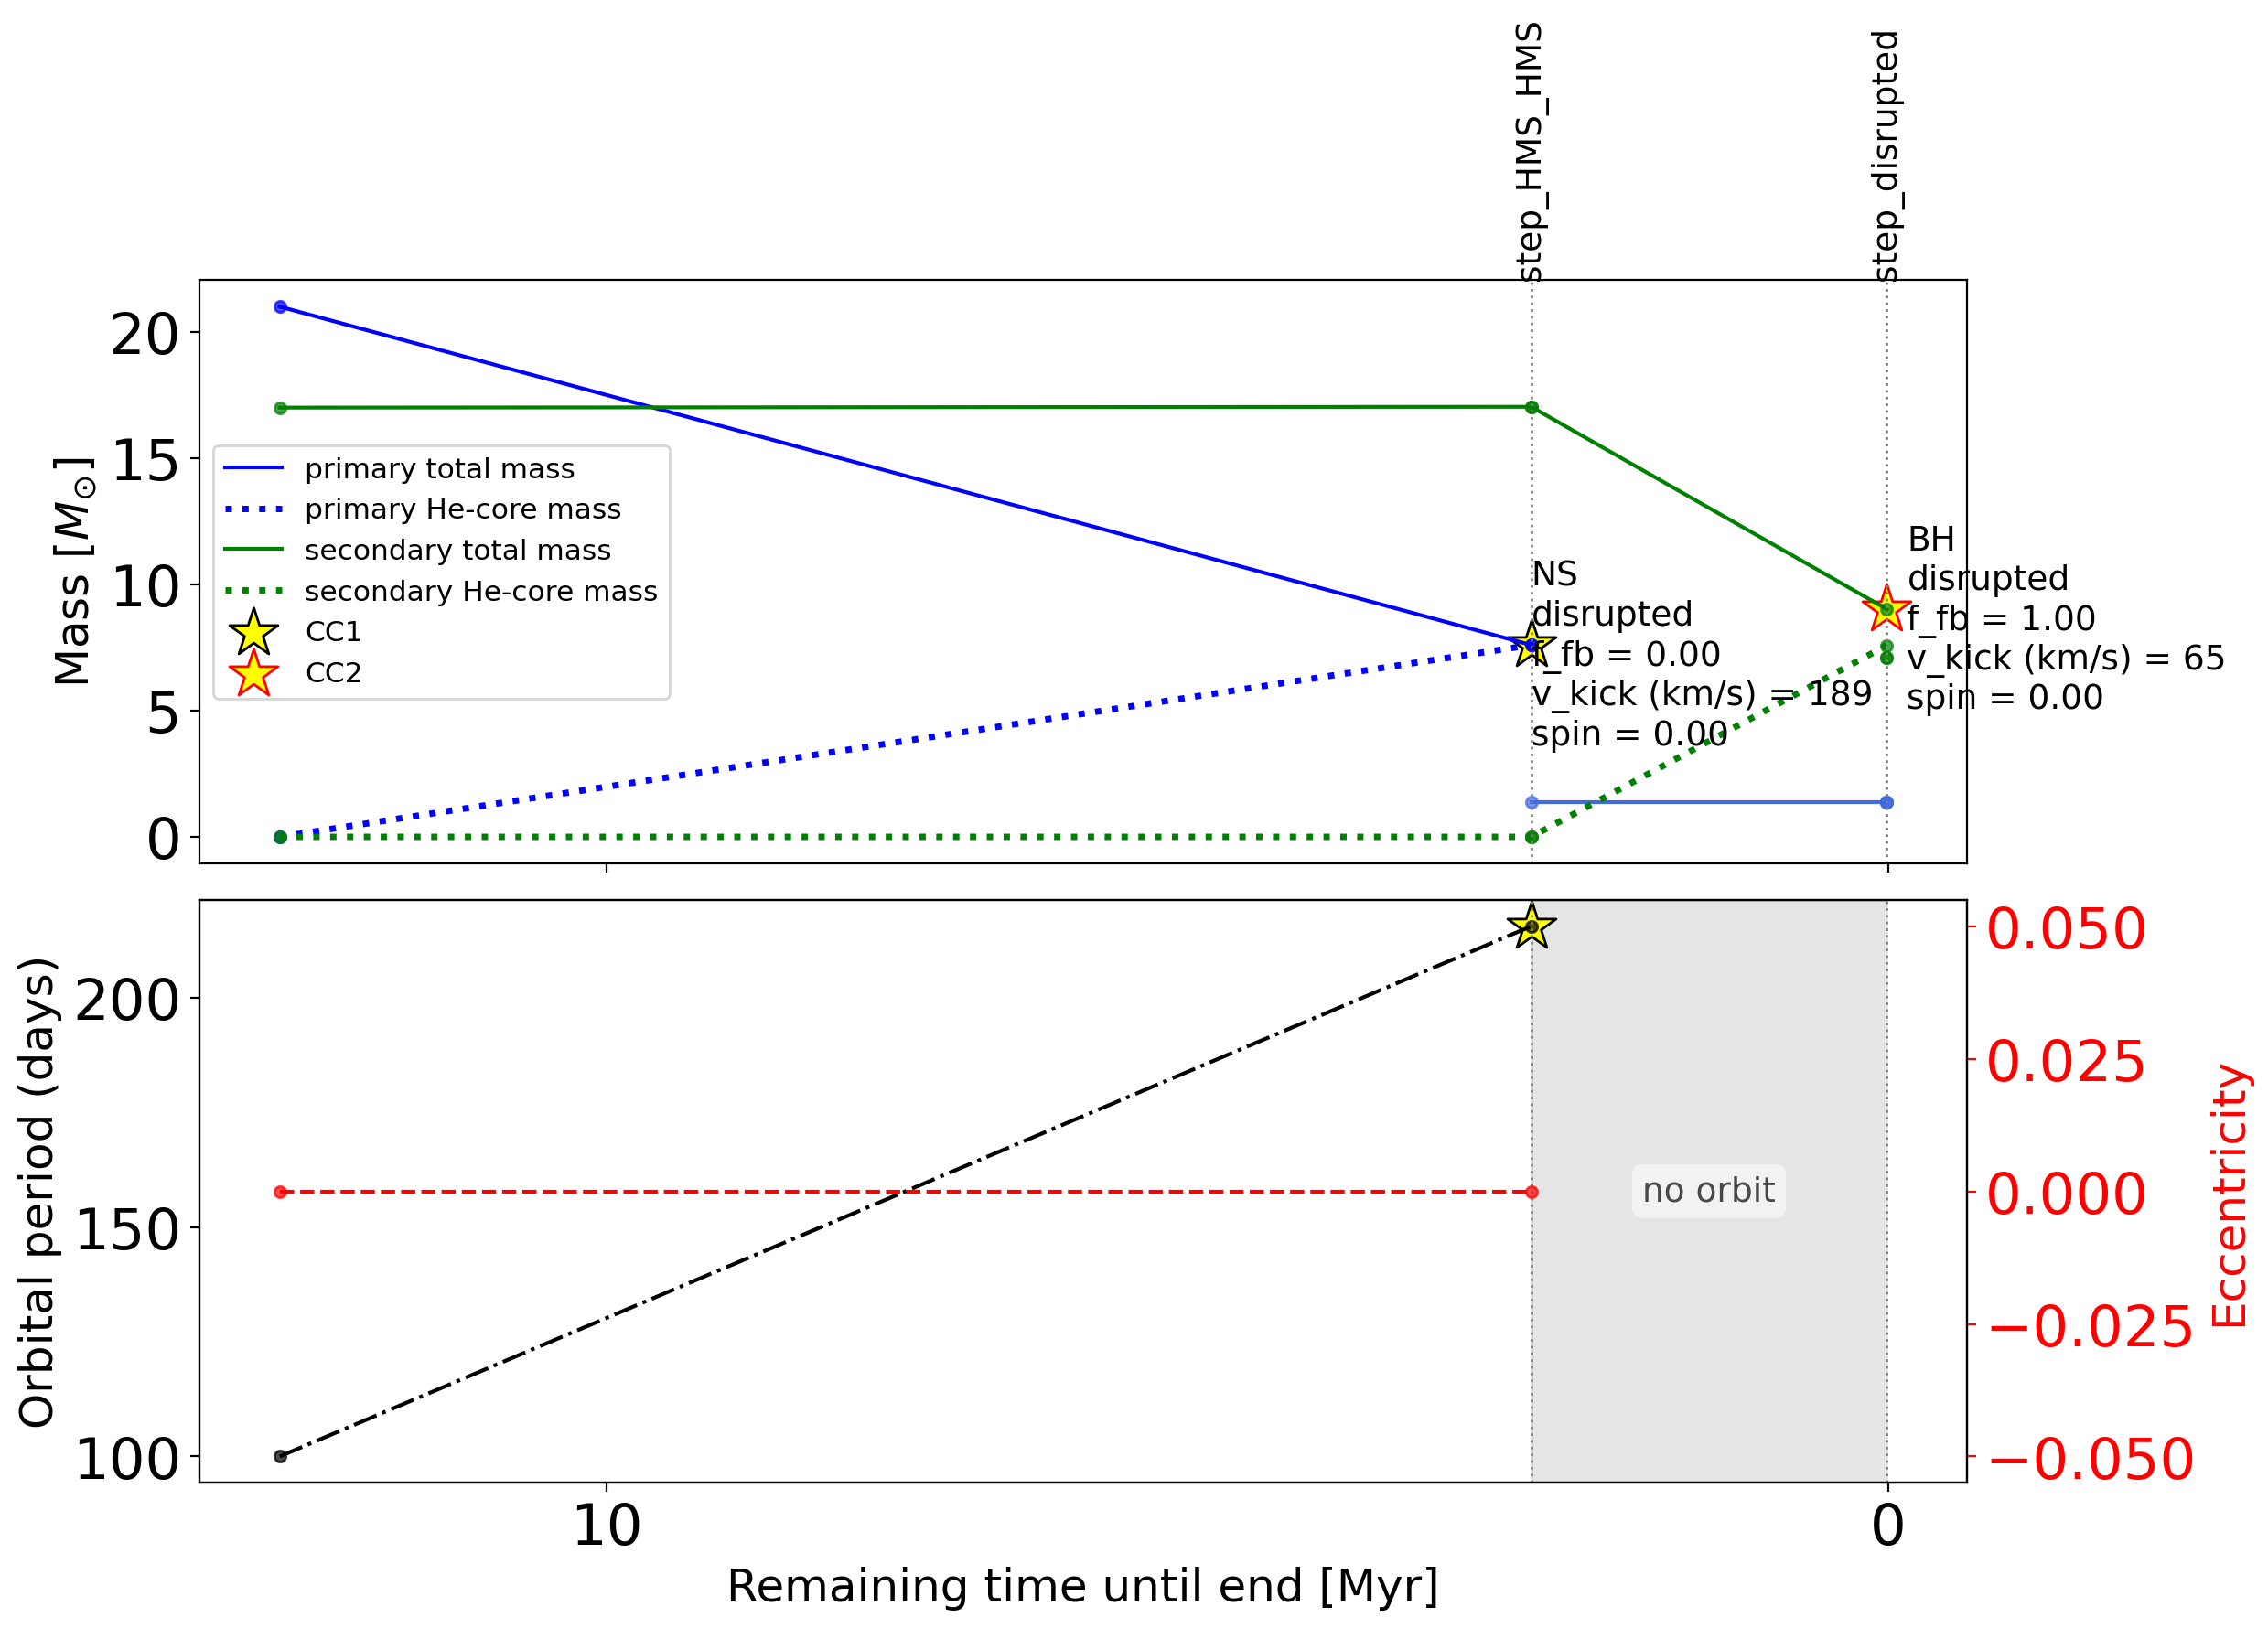

In [28]:
sim_prop.load_a_step("step_SN", (StepSN, MODEL_parameters))
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)
binary.evolve()

df_oneline=binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)
df=binary.to_df(extra_columns={'step_names':'string'})
plot_SN_evolution(df, df_oneline)


<div class="alert alert-success">

## Exercise: 

Evolve the same binary as before ($M_{1,\mathrm{init}} = 21 M_{\odot}$, $M_{2,\mathrm{init}} = 17 M_{\odot}$, and $P_{\mathrm{orb,init}} = 100 \,\mathrm{days}$), but use **SN_MODEL_v2_02** (the Fryer et al. 2012 delayed mechanism) and the new **SN_MODEL_v2_24** (the Patton & Sukhbold 2020 mapping with the Maltsev et al. 2025 explodability prescription) to estimate the outcome of each collapse(s).
   
</div>

# 3. Profiles and rotating collapsing stars 

In the last part, we want to briefly examine the calculation of a black hole spin based on the MESA profile of a rotating, collapsing star. Rotation is calculated in the MESA grids of POSYDON self-consistently.

We start again with the default options for our run. However, because we want to retain access to the stellar profile, we need to change the interpolation method from the default to `interpolation_method = 'nearest_neighbour'`. This allows us to access the stellar profile of the specific binary MESA run selected by the interpolation. For simplicity, we also turn off the SN kicks.

In [ ]:
#sim_prop = SimulationProperties.from_ini(path_to_ini, load_steps=True, metallicity=1.0, verbose=False)
sim_prop.load_a_step("step_HMS_HMS", (MS_MS_step, {'track_interpolation':False, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)
sim_prop.load_a_step("step_CO_HeMS", (CO_HeMS_step, {'track_interpolation':False, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)
sim_prop.load_a_step("step_CO_HMS_RLO", (CO_HMS_RLO_step, {'track_interpolation':False, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)
sim_prop.load_a_step("step_CO_HeMS_RLO", (CO_HeMS_RLO_step, {'track_interpolation':False, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)
sim_prop.load_a_step("step_SN", (StepSN, {'kick':False, 'use_interp_values':False}),metallicity=1.0) # so that we redo the calculation ourselves

Let's run one close binary system of very massive stars, with $M_{1} = 90  M_{\odot}$, $M_{2,init} = 35  M_{\odot}$, and $P_{\text{orb,init}} = 4$ days.

In [ ]:
m1_init = 90.00 # in Msun
m2_init = 35.00 # in Msun
p_init = 4. # in days

In [ ]:
STAR1, STAR2 = SingleStar(**{'mass': m1_init, 'state': 'H-rich_Core_H_burning'}), \
               SingleStar(**{'mass': m2_init, 'state': 'H-rich_Core_H_burning'})
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)
binary.evolve()

df_oneline = binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)
df = binary.to_df(extra_columns={'step_names':'string'})

In [ ]:
print(binary.star_1.state)
print(binary.star_1.profile)

The profile is `None` for `star_1` as it is a BH at the end of the binary evolution. However, the stellar profile of each star is available and retained in the history before `step_SN`, more precisely at carbon depletion, when the MESA run stopped.

The history of all properties in a single star object in POSYDON can be accessed as `binary.star_1/2.<propertyname>_history` 
So we can access the history of the profile of star_1 from `binary.star_1.profile_history`. 

In [ ]:
# Keep the profile in the evolution of star_1 at pre-CC1
import numpy as np
mask_CC1 = np.array(df['event']== "CC1")
idx_CC1 = np.nonzero(mask_CC1)[0][0] 
profile = binary.star_1.profile_history[idx_CC1]

Let's see the columns of the profile

In [ ]:
profile.dtype.names

These follow the column names and meanings as in MESA profiles. Documentation for kept profile columns : https://posydon.org/POSYDON/latest/components-overview/machine_learning/ProfileInterpolator.html

Now let's plot the rotational properties of the profile along the enclosed mass (and also along its radial coordinate)

In [ ]:
import matplotlib.pyplot as plt

mass = profile["mass"]
radius = profile["radius"] 
omega = profile["omega"]

# specific angular momentum j = omega * r^2
j = omega * (radius*cs.Rsun)**2 # in cgs

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------- Subplot 1: vs Mass ----------
ax1 = axes[0]
l1, = ax1.plot(mass, omega, marker="o", linestyle="-", color="tab:blue", label=r"$\omega$")
ax1.set_xlabel(r"Enclosed Mass [$M_{\odot}$]")
ax1.set_ylabel(r"$\omega$ (rad/s)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_title("Omega and Specific Angular Momentum vs Mass")
ax1.axvline(2.5, ls="--",lw =1.0, color="black")

# twin y-axis for j
ax1b = ax1.twinx()
l2, = ax1b.plot(mass, j, marker="s", linestyle="--", color="tab:red", label=r"$j_{\rm eq}=\omega r^2$")
ax1b.set_ylabel(r"$j_{\rm eq}$ (cgs units)", color="tab:red")
ax1b.tick_params(axis="y", labelcolor="tab:red")

# combined legend
ax1.legend(handles=[l1, l2], loc="upper center")

# ---------- Subplot 2: vs Radius ----------
ax2 = axes[1]
l3, = ax2.plot(radius, omega, marker="o", linestyle="-", color="tab:blue", label=r"$\omega$")
ax2.set_xlabel(r"Radial Coordinate [$R_{\odot}$]")
ax2.set_ylabel(r"$\omega$ (rad/s)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_title("Omega and Specific Angular Momentum vs Radius")

# twin y-axis for j
ax2b = ax2.twinx()
l4, = ax2b.plot(radius, j, marker="s", linestyle="--", color="tab:red", label=r"$j=\omega r^2$")
ax2b.set_ylabel(r"$j_{\rm eq}$ (cgs units)", color="tab:red")
ax2b.tick_params(axis="y", labelcolor="tab:red")

plt.tight_layout()
plt.show()


Note that the outer layers may have lower angular velocity but higher specific angular momentum due to being located far away from the rotational axis (assuming they are at the equator, else a polar dependence is involved)

Here we will see how the dimensionless spin parameter of the formed BH, $\alpha$, is calculated in POSYDON. It is defined as the ratio between the BH’s angular momentum $J$ and the maximum possible angular momentum for a BH of mass $M$:

$
\alpha = \frac{c J}{G M^{2}}
$

where $c$ is the speed of light and $G$ is the gravitational constant. It takes values between $0 \leq \alpha \leq 1$, with $\alpha = 0$ corresponding to a non-rotating (Schwarzschild) BH and $\alpha = 1$ to a maximally rotating (extremal Kerr) BH. In principle, the same dimensionless spin parameter can also be defined for a normal stellar object (and it is kept as a value in the history of a SingleStar object in POSYDON), in which case values $>1$ are possible because there is no corresponding event-horizon limit.


In [ ]:
BH_spin = binary.star_1.spin_history[idx_CC1+1] 
print(f"a_BH = {BH_spin:.3f}")

This is the BH spin immediately after CC1, without accounting for any subsequent spin evolution due to additional accretion from the secondary later in the evolution, although POSYDON does calculate this subsequent spin evolution.

To calculate the above BH spin at collapse, we follow the [Batta & Ramirez-Ruiz (2019) prescription](https://ui.adsabs.harvard.edu/abs/2019arXiv190404835B/abstract). We first assume that the inner part of the stellar profile, `mass_central_BH` $= 2.51,M_{\odot}$ by default (shown as the vertical black line above), collapses to form the initial BH, after accounting for neutrino mass loss. The remaining layers then collapse shell by shell, with part falling directly onto the BH, adding its full mass and angular momentum, and part forming an accretion disk if it has sufficient angular momentum. Part of the disk is accreted onto the BH (`m_disk_accreted`), while part of its mass-energy is radiated away (`m_disk_radiated`). This also provides an estimate of the energy budget relevant for the Blandford--Znajek mechanism and jet formation in the collapsar model for long gamma-ray bursts.


<img src="./Batta_et_al_collapsing_shells.png" alt="Collapsing shells" width="30%">

As seen above, the BH spin has already been calculated automatically, but here we want to reproduce the calculation manually in order to better understand the process. We first restore the binary to its pre-`CC1` state, i.e. before `step_SN`, so that it is ready for the collapse calculation. For more information about the `restore` function, see [here](https://posydon.org/POSYDON/latest/_modules/posydon/binary_evol/singlestar.html#SingleStar.restore).

In [ ]:
binary.star_1.restore(idx_CC1) 
star_for_collapse =  binary.star_1

In [ ]:
from posydon.binary_evol.SN.profile_collapse import do_core_collapse_BH  #https://posydon.org/POSYDON/latest/api_reference/posydon.binary_evol.SN.html#posydon.binary_evol.SN.profile_collapse.do_core_collapse_BH
pre_CC_mass = star_for_collapse.mass
do_core_collapse_BH(star_for_collapse, mass_central_BH=2.51, mass_collapsing = pre_CC_mass,  neutrino_mass_loss = .5, verbose = True)

The inner `mass_central_BH` first collapses to a $2.51,M_{\odot}$ BH with a spin of $a = 0.135$. The remaining collapsing shells continue to increase the BH mass and angular momentum, with some shells having enough angular momentum to form a very low-mass disk, part of which is also accreted. The final BH has a mass of $12.025,M_{\odot}$, with part of the stellar mass lost through neutrinos, and a spin of $a = 0.157$, consistent with the value obtained earlier.

It is left as a homework exercise for anyone interested to explore the [`do_core_collapse_BH`](https://posydon.org/POSYDON/latest/api_reference/posydon.binary_evol.SN.html#posydon.binary_evol.SN.profile_collapse.do_core_collapse_BH) function in POSYDON, together with the Batta & Ramirez-Ruiz paper, to better understand the calculated quantities and the estimated energy that may be released as feedback through jet formation.

<div class="alert alert-success">

## Exercise: 

Make the same calculation for the BH formed from star_2. Is there any disk formed during the collapse of the slowly rotating star?
   
</div>

In [ ]:
## Fill in ##

<div class="alert alert-warning" style="margin-top: 20px">

<details>
<summary><b>Hint</b></summary>
We need to restore star_2 to its state before its step_SN. First, we need to identify the evolutionary timestep at which this occurred.
</details>

<div class="alert alert-warning" style="margin-top: 20px">

<details>
<summary><b>Solution</b></summary>
    
```python
mask_CC2 = np.array(df['event']== "CC2")
idx_CC2 = np.flatnonzero(mask_CC2)[0]
profile = binary.star_2.profile_history[idx_CC2] # profile pre-CC2
BH_spin = binary.star_2.spin_history[idx_CC2+1] #post-CC2
print(f"a_BH = {BH_spin:.3f}")
binary.star_2.restore(idx_CC2) 
star2_for_collapse =  binary.star_2
final_BH_mass = star2_for_collapse.mass
do_core_collapse_BH(star2_for_collapse, mass_central_BH=2.51, mass_collapsing = final_BH_mass,  neutrino_mass_loss = .5, verbose = True)
```
</details>

# [Optional] Detailed Time Evolution of the Binary from Part 1

Apart from the BH-spin calculation in Part 3 (for which we used the stellar profile obtained with `interpolation_method = 'nearest_neighbour'`), in Parts 1 and 2 we evolved each `step_MESA` phase of the binary system using the `"linear3c_kNN"` interpolation method, which provides initial/final interpolation. In `step_SN`, we also determined the outcome of each core-collapse event using precomputed interpolated values by setting `use_interp_values=True`.

Now, we will learn how to run a binary system while retaining more detailed information about its evolutionary history rather than only the initial and final values from each POSYDON grid.

For this run, first the simulation propoerties file must be modified by reloading the MESA steps `step_HMS_HMS`, `step_CO_HMS_RLO`, `step_CO_HeMS`, and `step_CO_HeMS_RLO`, setting `track_interpolation = True`. This option is currently available only if `interpolation_method = 'nearest_neighbour'`. In this way, we can access the downsampled history output of the nearest-neighbour MESA run.

This is an example of how your `.ini` file should be structured, specifically for the [step_HMS_HMS] section. 

**[step_HMS_HMS]**  
  import = ['posydon.binary_evol.MESA.step_mesa', 'MS_MS_step']
  absolute_import = None  
  interpolation_path = None  
  interpolation_filename = None    
  **interpolation_method = 'nearest_neighbour'**  
  save_initial_conditions = True  
  **track_interpolation = True**  
  stop_method = 'stop_at_max_time'    
  stop_star = 'star_1'    
  stop_var_name = None  
  stop_value = None  
  stop_interpolate = True


In [ ]:
#sim_prop = SimulationProperties.from_ini(path_to_ini, load_steps=True, metallicity=1.0, verbose=False)
sim_prop.load_a_step("step_HMS_HMS", (MS_MS_step, {'track_interpolation':True, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)
sim_prop.load_a_step("step_CO_HeMS", (CO_HeMS_step, {'track_interpolation':True, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)
sim_prop.load_a_step("step_CO_HMS_RLO", (CO_HMS_RLO_step, {'track_interpolation':True, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)
sim_prop.load_a_step("step_CO_HeMS_RLO", (CO_HeMS_RLO_step, {'track_interpolation':True, 'interpolation_method':'nearest_neighbour'}),metallicity=1.0)

Additionally, in the steps `[step_detached]`, `[step_initially_single]`, `[step_disrupted]`, and `[step_merged]`, include the command `n_o_steps_history = 50`.
(Here, 50 is just an example value and can be adjusted as needed.)

This ensures that the output contains 50 timesteps equally spaced in time during these steps. An alternative is to use `dt`, which specifies the timestep in absolute years (though this can be less convenient for very short or very long evolutionary phases).

In [ ]:
sim_prop.load_a_step("step_disrupted", (DisruptedStep, {'n_o_steps_history': 50 }))
sim_prop.load_a_step("step_detached", (detached_step, {'n_o_steps_history': 50 }))
sim_prop.load_a_step("step_merged", (MergedStep, {'n_o_steps_history': 50 }))
sim_prop.load_a_step("step_initially_single", (InitiallySingleStep, {'n_o_steps_history': 50 }))

Let’s evolve the same initial binary as in Part 1. However, because we now set `use_interp_values`=False, the core-collapse outcome is recalculated from the available stellar profile/core properties rather than taken from the precomputed interpolated SN values. Therefore, although the initial conditions are identical, the post-SN evolution may differ.

In [ ]:
m1_init = 28.15 # in Msun
m2_init = 19.7 # in Msun
p_init = 10 # in days

dict_initial_binary = {'time': 0.0, 'state': 'detached', 'event': 'ZAMS', 'eccentricity': 0.0}

STAR1, STAR2 = SingleStar(**{'mass': m1_init, 'state': 'H-rich_Core_H_burning', 'natal_kick_velocity': 41, 'natal_kick_azimuthal_angle': 0, 'natal_kick_polar_angle': 0}), \
               SingleStar(**{'mass': m2_init, 'state': 'H-rich_Core_H_burning'})

sim_prop.load_a_step("step_SN", (StepSN, {'kick':True, 'use_interp_values':False}),metallicity=1.0) # so that we redo the calculation ourselves
binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)

S1_kwargs = {
    "only_select_columns": ["spin"],
    "scalar_names": ["natal_kick_velocity", "SN_type", "f_fb",'h1_mass_ej', 'he4_mass_ej', 'avg_c_in_c_core_at_He_depletion', 'co_core_mass_at_He_depletion']
}
S2_kwargs = S1_kwargs.copy()

binary = BinaryStar(STAR1, STAR2, **{**dict_initial_binary, 'orbital_period': p_init}, properties=sim_prop)

binary.evolve()

df=binary.to_df(extra_columns={'step_names':'string'})
df_oneline=binary.to_oneline_df(S1_kwargs=S1_kwargs, S2_kwargs=S2_kwargs)

In [ ]:
from plotting_functions_CC  import plot_SN_evolution # a function made for this lab to visualize the time evolution of a systems, focusing on its CC1/2 properties
plot_SN_evolution(df, df_oneline)